In [1]:
import os
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import plotly.graph_objects as go
import plotly.colors as pc
from collections import Counter
from scipy.spatial.distance import jensenshannon
from scipy.stats import entropy as scipy_entropy

In [77]:


# --------------------------------------------------
# Style
# --------------------------------------------------

sns.set_style("white")
sns.set_context("talk")


# --------------------------------------------------
# File paths
# --------------------------------------------------

mouse_files = {
    "DMS High Tier": r"Y:\3darena_chemogenetic\c1_041626\042226_m7dms_hm4di\cluster_output_042226_m7dms_hm4di_hightier+baseline+inhibition\Results\test1\Cluster_detail_results.csv",
}



In [78]:

# --------------------------------------------------
# Load + label data
# --------------------------------------------------

def load_mouse_data(file_path, mouse_name):
    df = pd.read_csv(file_path)

    df = df[["ClusterIdx", "Timestamp", "Folder_Name"]].copy()
    df = df.dropna(subset=["ClusterIdx", "Timestamp", "Folder_Name"])
    df["Folder_Name"] = df["Folder_Name"].replace({
        1.0: "Baseline",
        2.0: "Inhibition",
    })

    df["ClusterIdx"] = pd.to_numeric(df["ClusterIdx"], errors="coerce")
    df["Timestamp"] = pd.to_numeric(df["Timestamp"], errors="coerce")
    df = df.dropna(subset=["ClusterIdx", "Timestamp"])

    df["ClusterIdx"] = df["ClusterIdx"].astype(int)
    df["Folder_Name"] = df["Folder_Name"].astype(str).str.strip()
    df["Mouse"] = mouse_name

    folder = df["Folder_Name"].str.lower()
    df["Arena"] = np.select(
        [
            folder.str.contains("baseline", na=False),
            folder.str.contains("inhibition", na=False),
        ],
        [
            "Baseline",
            "Inhibition",
        ],
        default="Unknown"
    )

    df = df.sort_values(["Folder_Name", "Timestamp"]).reset_index(drop=True)
    return df


# --------------------------------------------------
# Load all mice
# --------------------------------------------------

all_dfs = []

for mouse_name, file_path in mouse_files.items():
    df_mouse = load_mouse_data(file_path, mouse_name)
    all_dfs.append(df_mouse)

df_all = pd.concat(all_dfs, ignore_index=True)

print("\n================ DATA CHECK ================\n")
print("Total rows:", len(df_all))
print("Clusters:", df_all["ClusterIdx"].nunique())

print("\nArena counts:")
print(df_all["Arena"].value_counts())

print("\nArena by mouse:")
print(df_all.groupby(["Mouse", "Arena"]).size())



================ DATA CHECK ================

Total rows: 23866
Clusters: 40

Arena counts:
Arena
Baseline      11964
Inhibition    11902
Name: count, dtype: int64

Arena by mouse:
Mouse          Arena     
DMS High Tier  Baseline      11964
               Inhibition    11902
dtype: int64


In [79]:


# --------------------------------------------------
# Transition helpers
# --------------------------------------------------

def create_transitions(data, include_self_transitions=False):
    transitions = Counter()

    data = data.sort_values("Timestamp")
    clusters = data["ClusterIdx"].to_numpy()

    if len(clusters) < 2:
        return transitions

    for i in range(len(clusters) - 1):
        c1 = clusters[i]
        c2 = clusters[i + 1]

        if not include_self_transitions and c1 == c2:
            continue

        transitions[(c1, c2)] += 1

    return transitions


def pooled_transitions(df, include_self_transitions=False):
    total = Counter()

    for _, session_df in df.groupby("Folder_Name"):
        total.update(
            create_transitions(
                session_df,
                include_self_transitions=include_self_transitions
            )
        )

    return dict(total)


def transitions_to_matrix(transitions, cluster_list):
    mat = pd.DataFrame(
        0,
        index=cluster_list,
        columns=cluster_list,
        dtype=float
    )

    for (c1, c2), count in transitions.items():
        if c1 in mat.index and c2 in mat.columns:
            mat.loc[c1, c2] = count

    return mat


def normalize(mat):
    row_sums = mat.sum(axis=1).replace(0, np.nan)
    return mat.div(row_sums, axis=0).fillna(0)


def transition_probability_dict(transitions):
    total = sum(transitions.values())

    if total == 0:
        return {}

    return {
        transition: count / total
        for transition, count in transitions.items()
    }


In [50]:

# --------------------------------------------------
# 4F Shared-Motif-Only Heatmaps
# Separate figures
# --------------------------------------------------

def get_shared_transition_mats(trans_a, trans_b):
    shared = set(trans_a.keys()).intersection(set(trans_b.keys()))

    if len(shared) == 0:
        return None, None

    shared_a = {k: trans_a[k] for k in shared}
    shared_b = {k: trans_b[k] for k in shared}

    clusters = sorted(set([c for pair in shared for c in pair]))

    mat_a = normalize(transitions_to_matrix(shared_a, clusters))
    mat_b = normalize(transitions_to_matrix(shared_b, clusters))

    return mat_a, mat_b


def plot_single_shared_heatmap(mat, title):
    plt.figure(figsize=(10, 8))

    if mat is None or mat.empty:
        plt.text(
            0.5,
            0.5,
            "No shared motifs",
            ha="center",
            va="center",
            fontsize=16
        )
        plt.title(title)
        plt.axis("off")
        plt.tight_layout()
        plt.show()
        return

    vmax = mat.to_numpy().max()

    if vmax == 0:
        vmax = 1

    cmap = sns.light_palette("blue", as_cmap=True)

    sns.heatmap(mat, cmap=cmap, vmin=0, vmax=vmax)
    plt.title(title)
    plt.xlabel("To Cluster")
    plt.ylabel("From Cluster")
    plt.tight_layout()
    plt.show()

In [51]:

def plot_4f_shared_heatmaps_for_mouse(df_mouse, mouse_name):
    df_flat = df_mouse[df_mouse["Arena"] == "Baseline"].copy()
    flat_trans = pooled_transitions(df_flat, include_self_transitions=False)

    comparisons = [
        ("Inhibition", df_mouse[df_mouse["Arena"] == "Inhibition"].copy()),
    ]

    for label, df_group in comparisons:
        print(f"\nMaking 4F shared heatmaps for {mouse_name}: Baseline vs {label}")

        group_trans = pooled_transitions(df_group, include_self_transitions=False)

        group_mat, flat_mat = get_shared_transition_mats(
            group_trans,
            flat_trans
        )

        plot_single_shared_heatmap(
            group_mat,
            f"4F {mouse_name}: Baseline vs {label} - {label} Shared-Motif Heatmap"
        )

        plot_single_shared_heatmap(
            flat_mat,
            f"4F {mouse_name}: Baseline vs {label} - Flat Shared-Motif Heatmap"
        )



In [13]:

# --------------------------------------------------
# Jensen-Shannon Divergence
# --------------------------------------------------

def transitions_to_prob_vector(transitions, all_keys):
    total = sum(transitions.values())

    if total == 0:
        return np.zeros(len(all_keys))

    return np.array([
        transitions.get(k, 0) / total
        for k in all_keys
    ])


def compute_js_divergence(trans_a, trans_b):
    all_keys = list(set(trans_a.keys()).union(set(trans_b.keys())))

    if len(all_keys) == 0:
        print("List 'all_keys' has a length of 0")
        return np.nan

    p = transitions_to_prob_vector(trans_a, all_keys)
    q = transitions_to_prob_vector(trans_b, all_keys)

    js_distance = jensenshannon(p, q)
    js_divergence = js_distance ** 2

    return js_divergence


def compute_transition_entropy(transitions):
    """Shannon entropy (bits) of the transition probability distribution."""
    total = sum(transitions.values())
    if total == 0:
        return np.nan
    probs = np.array(list(transitions.values())) / total
    return scipy_entropy(probs, base=2)  # bits; drop base=2 for nats

# --------------------------------------------------
# Compute JS divergence by mouse
# --------------------------------------------------

js_rows = []
entropy_rows = []

arena_order = ["Baseline", "Inhibition"]

for mouse_name in df_all["Mouse"].unique():
    df_mouse = df_all[df_all["Mouse"] == mouse_name].copy()

    df_flat = df_mouse[df_mouse["Arena"] == "Baseline"].copy()
    df_3d = df_mouse[df_mouse["Arena"] == "Inhibition"].copy()

    flat_trans = pooled_transitions(df_flat, include_self_transitions=False)
    d3_trans = pooled_transitions(df_3d, include_self_transitions=False)

    js_rows.append({
        "Mouse": mouse_name,
        "Comparison": "Baseline vs Inhibition",
        "JS Divergence": compute_js_divergence(flat_trans, d3_trans)
    })
    for condition_label, condition_key in [("Baseline", "Baseline"), ("Inhibition", "Inhibition")]:
        df_cond = df_mouse[df_mouse["Arena"] == condition_key].copy()
        trans = pooled_transitions(df_cond, include_self_transitions=False)
        entropy_rows.append({
            "Mouse": mouse_name,
            "Arena": condition_label,
            "Entropy (bits)": compute_transition_entropy(trans)
        })

    for arena in arena_order:
        df_arena = df_mouse[df_mouse["Arena"] == arena].copy()
        arena_trans = pooled_transitions(df_arena, include_self_transitions=False)

        entropy_rows.append({
            "Mouse": mouse_name,
            "Arena": arena,
            "Entropy (bits)": compute_transition_entropy(arena_trans)
        })

df_js = pd.DataFrame(js_rows)
df_entropy = pd.DataFrame(entropy_rows)

print("\n================ JS DIVERGENCE TABLE ================\n")
print(df_js)

print("\n================ ENTROPY TABLE ================\n")
print(df_entropy)


================ JS DIVERGENCE TABLE ================

          Mouse              Comparison  JS Divergence
0  Stitched DMS  Baseline vs Inhibition       0.050018

================ ENTROPY TABLE ================

          Mouse       Arena  Entropy (bits)
0  Stitched DMS    Baseline       10.551238
1  Stitched DMS  Inhibition       10.590557
2  Stitched DMS    Baseline       10.551238
3  Stitched DMS  Inhibition       10.590557


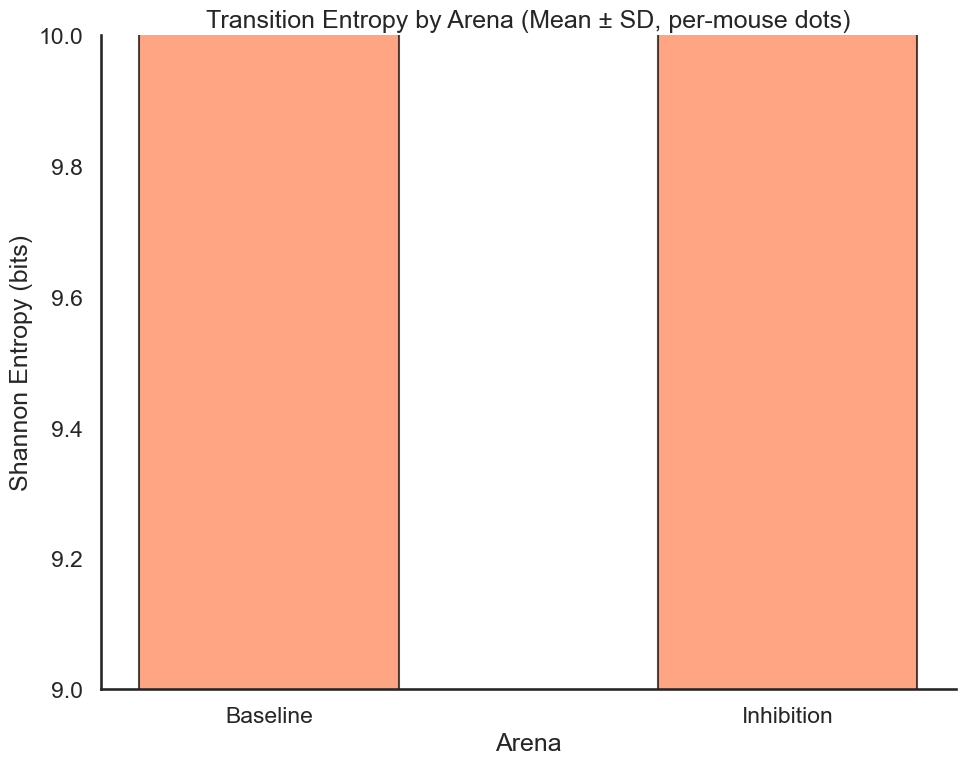

In [14]:

arena_order_plot = ["Baseline", "Inhibition"]

# Filter to only arenas that exist in the data
existing_arenas = df_entropy["Arena"].unique()
plot_order = [a for a in arena_order_plot if a in existing_arenas]

plt.figure(figsize=(10, 8))
ax = plt.gca()

# --- Bar: group mean ---
df_grouped = df_entropy.groupby("Arena")["Entropy (bits)"].agg(["mean", "std"]).reindex(plot_order)

x_pos = np.arange(len(plot_order))
bar_width = 0.5

ax.bar(
    x_pos,
    df_grouped["mean"],
    width=bar_width,
    color="coral",
    edgecolor="black",
    linewidth=1.5,
    alpha=0.7,
    zorder=2
)

# --- Error bars: std ---
# ax.errorbar(
#     x_pos,
#     df_grouped["mean"],
#     yerr=df_grouped["std"],
#     fmt="none",
#     color="black",
#     capsize=5,
#     linewidth=1.5,
#     zorder=3
# )

# --- Dots: individual mice ---
mice = df_entropy["Mouse"].unique()
colors = sns.color_palette("tab10", n_colors=len(mice))
mouse_color = dict(zip(mice, colors))

# for arena_idx, arena in enumerate(plot_order):
#     df_arena = df_entropy[df_entropy["Arena"] == arena]
#     for _, row in df_arena.iterrows():
#         ax.scatter(
#             arena_idx,
#             row["Entropy (bits)"],
#             color=mouse_color[row["Mouse"]],
#             s=80,
#             zorder=4,
#             edgecolors="white",
#             linewidths=0.5
#         )

# # --- Legend for mice ---
# handles = [
#     plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=mouse_color[m],
#                markersize=9, label=m)
#     for m in mice
# ]
# ax.legend(handles=handles, title="Mouse", bbox_to_anchor=(1.01, 1), loc="upper left")

ax.set_xticks(x_pos)
ax.set_xticklabels(plot_order)
                   #, rotation=45, ha="right")
ax.set_xlabel("Arena")
ax.set_ylabel("Shannon Entropy (bits)")
ax.set_title("Transition Entropy by Arena (Mean ± SD, per-mouse dots)")
ax.set_ylim(9,10)
sns.despine()
plt.tight_layout()
plt.savefig("transition_entropy_by_arena.png", dpi=300)
plt.show()

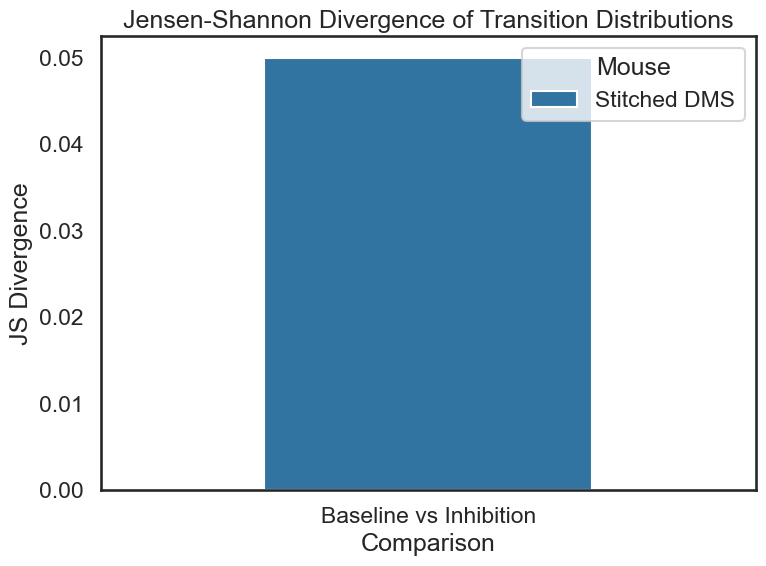

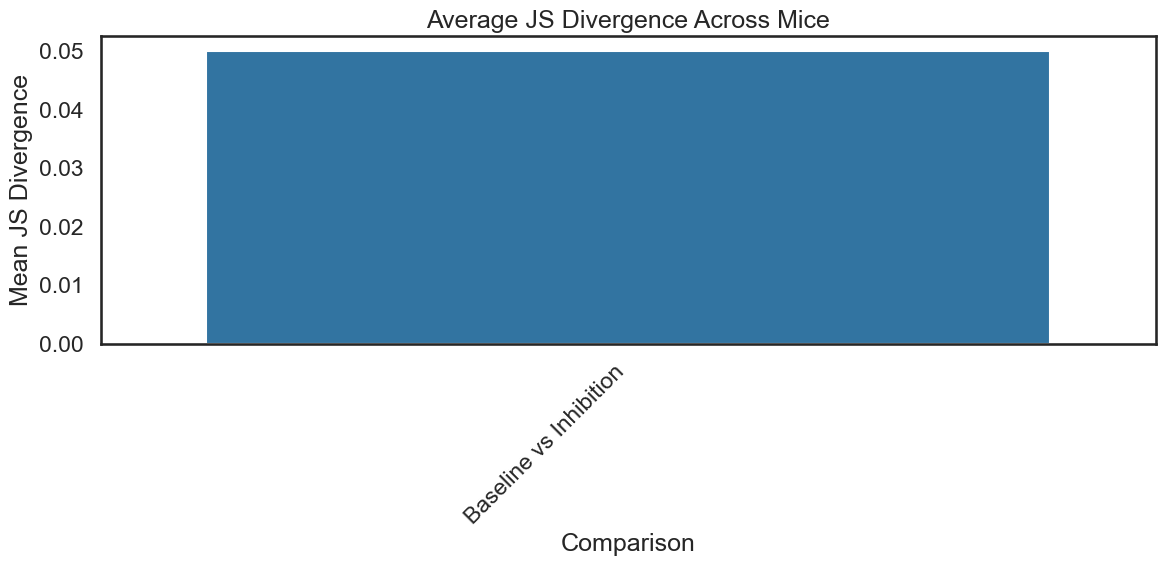

In [15]:
# --------------------------------------------------
# JS divergence bar graph by mouse
# --------------------------------------------------

plt.figure(figsize=(8, 6))

sns.barplot(
    data=df_js,
    width=.5,
    x="Comparison",
    y="JS Divergence",
    hue="Mouse"
)

plt.title("Jensen-Shannon Divergence of Transition Distributions")
plt.xlabel("Comparison")
plt.ylabel("JS Divergence")
#plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(r"JS Divergence of Transition Distributions.png", dpi=300)
plt.show()


# --------------------------------------------------
# Average JS divergence across mice
# --------------------------------------------------

df_js_avg = (
    df_js
    .groupby("Comparison", as_index=False)["JS Divergence"]
    .mean()
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_js_avg,
    x="Comparison",
    y="JS Divergence"
)

plt.title("Average JS Divergence Across Mice")
plt.xlabel("Comparison")
plt.ylabel("Mean JS Divergence")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [30]:
def plot_transition_graph(
    subset_transition_matrix,
    transitions=40,
    node_scaling=4,
    edge_scaling=6,
    text_scaling=0.4,
    arrow_reduction_factor=0.03,
    title="Transition Graph",
    colorscale="Blues",
    save=False,
    path=None,
    export_csv=False,
    csv_path=None
):
    import plotly.colors as pc

    def weight_to_color(w, vmin, vmax):
        if vmax == vmin:
            return "rgb(8,48,107)"
        norm = (w - vmin) / (vmax - vmin)
        return pc.sample_colorscale(colorscale, norm)[0]

    edges = []

    for i in subset_transition_matrix.index:
        for j in subset_transition_matrix.columns:
            weight = subset_transition_matrix.loc[i, j]
            if weight > 0 and i != j:
                edges.append((str(i), str(j), float(weight)))

    if len(edges) == 0:
        print(f"No nonzero transitions found for: {title}")
        return

    top_edges = sorted(edges, key=lambda x: x[2], reverse=True)[:transitions]

    top_nodes = set(
        [u for u, v, w in top_edges]
        + [v for u, v, w in top_edges]
    )

    G = nx.DiGraph()
    G.add_nodes_from(top_nodes)

    for u, v, w in top_edges:
        G.add_edge(u, v, weight=w)

    if G.number_of_nodes() == 0:
        print(f"No graph created for: {title}")
        return

    ordered_nodes = sorted(G.nodes(), key=lambda x: int(float(x)))
    pos = nx.circular_layout(ordered_nodes)

    node_degrees = dict(G.degree())
    node_size = [48 for node in G.nodes()]
    text_size = [18 for node in G.nodes()]
    pixel_to_coord = 2.4 / 800

    node_radius = [
        size * pixel_to_coord * 0.5
        for size in node_size
    ]

    node_radii = {
        node: r
        for node, r in zip(G.nodes(), node_radius)
    }

    edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
    vmin_w = min(edge_weights)
    vmax_w = 1#max(edge_weights)

    node_degrees = dict(G.degree())
    degree_values = [node_degrees[node] for node in G.nodes()]

    node_trace = go.Scatter(
        x=[pos[node][0] for node in G.nodes()],
        y=[pos[node][1] for node in G.nodes()],
        text=[str(int(float(node))) for node in G.nodes()],
        mode="markers+text",
        hoverinfo="text",
        marker=dict(
            size=48,
            color=degree_values,
            colorscale=[
                [0.0, "rgb(255,245,240)"],
                [1.0, "rgb(186, 25, 6)"]
            ],
            showscale=True,
            colorbar=dict(
                title="Degree",
                x=1.02,          # position of the degree colorbar
                xanchor="left",
                thickness=15,
                len=0.5,
                y=0.5,
                yanchor="middle"
            ),
            cmin=0,
            cmax=10,
            line=dict(width=1, color="black")
        ),
        textfont=dict(size=18, color="black")
    )

    # --- dummy trace for the Blues (edge weight) colorbar ---
    weight_colorbar_trace = go.Scatter(
        x=[None],
        y=[None],
        mode="markers",
        marker=dict(
            color=[vmin_w, vmax_w],
            colorscale=colorscale,
            showscale=True,
            colorbar=dict(
                title="Weight",
                x=1.12,          # offset to the right of the Degree colorbar
                xanchor="left",
                thickness=15,
                len=0.5,
                y=0.5,
                yanchor="middle"
            ),
            cmin=vmin_w,
            cmax=vmax_w,
        ),
        hoverinfo="none"
    )

    edge_traces = []

    for u, v in sorted(G.edges(), key=lambda e: G[e[0]][e[1]]["weight"]):
        x0, y0 = pos[u]
        x1, y1 = pos[v]

        edge_weight = G[u][v]["weight"]
        color = weight_to_color(edge_weight, vmin_w, vmax_w)

        dx = x1 - x0
        dy = y1 - y0
        dist = np.sqrt(dx * dx + dy * dy)

        if dist == 0:
            continue

        x_start = x0 + dx * (node_radii[u] / dist)
        y_start = y0 + dy * (node_radii[u] / dist)
        x_end   = x1 - dx * (node_radii[v] / dist) - dx * arrow_reduction_factor
        y_end   = y1 - dy * (node_radii[v] / dist) - dy * arrow_reduction_factor

        edge_traces.append(
            go.Scatter(
                x=[x_start, x_end, None],
                y=[y_start, y_end, None],
                line=dict(width=2, color=color),
                hoverinfo="text",
                text=[f"{u} → {v}<br>p={edge_weight:.3f}"],
                mode="lines"
            )
        )

    # --- add weight_colorbar_trace alongside existing traces ---
    fig = go.Figure(data=[*edge_traces, node_trace, weight_colorbar_trace])

    for u, v in sorted(G.edges(), key=lambda e: G[e[0]][e[1]]["weight"]):
        x0, y0 = pos[u]
        x1, y1 = pos[v]

        edge_weight = G[u][v]["weight"]
        color = weight_to_color(edge_weight, vmin_w, vmax_w)

        dx = x1 - x0
        dy = y1 - y0
        dist = (dx ** 2 + dy ** 2) ** 0.5

        x1_arrow = x1 - dx * arrow_reduction_factor if dist > 0 else x1
        y1_arrow = y1 - dy * arrow_reduction_factor if dist > 0 else y1

        fig.add_annotation(
            ax=x0, ay=y0,
            x=x1_arrow, y=y1_arrow,
            xref="x", yref="y",
            axref="x", ayref="y",
            showarrow=True,
            arrowhead=2,
            arrowsize=0.8,
            arrowwidth=2,
            arrowcolor=color
        )

    fig.update_layout(
        title={"text": title, "font": {"size": 16}},
        width=1000,   # slightly wider to accommodate both colorbars
        height=900,
        paper_bgcolor="#d9dde3",
        plot_bgcolor="#d9dde3",
        showlegend=False,
        hovermode="closest",
        margin=dict(b=10, l=10, r=120, t=40),  # extra right margin for colorbars
        xaxis=dict(
            range=[-1.15, 1.15],
            showgrid=False, zeroline=False, showticklabels=False
        ),
        yaxis=dict(
            range=[-1.15, 1.15],
            scaleanchor="x", scaleratio=1,
            showgrid=False, zeroline=False, showticklabels=False
        )
    )

    if save and path:
        base_path, _ = os.path.splitext(path)
        fig.write_image(f"{base_path}.png")
        fig.write_image(f"{base_path}.svg")

    if export_csv and csv_path:
        node_sizes = {
            node: max(node_degrees[node] * node_scaling + 18, 18)
            for node in G.nodes()
        }
        with open(csv_path, mode="w", newline="") as csvfile:
            csvwriter = csv.writer(csvfile)
            csvwriter.writerow(["starting cluster", "ending cluster", "edge weight", "node size"])
            for u, v, w in top_edges:
                node_size_u = node_sizes.get(u, 18)
                csvwriter.writerow([u, v, w, node_size_u])
        print(f"CSV file '{csv_path}' has been created with {len(top_edges)} edges.")

    fig.show()

In [31]:
def plot_combined_shared_transition_graphs(df_mouse, mouse_name, graph_top_n=40, save=False):
    """
    Three transition graphs using all transitions present in ANY arena in the group:
      - Combined: all 5 arenas (Restricted, Non-restricted, Low, Medium, High)
      - 2D:       Restricted + Non-restricted
      - 3D:       Low + Medium + High
    Edge weights reflect combined frequency across the relevant arenas.
    """

    arena_groups = {
        "Combined": ["Baseline", "Inhibition"],
        "Baseline": ["Baseline"],
        "Inhibition":   ["Inhibition"],
    }

    # --- get per-arena transitions ---
    arena_trans = {}
    for arena in ["Baseline", "Inhibition"]:
        df_arena = df_mouse[df_mouse["Arena"] == arena].copy()
        arena_trans[arena] = pooled_transitions(df_arena, include_self_transitions=False)

    for group_label, arenas in arena_groups.items():

        # --- union: all transitions present in ANY arena in the group ---
        trans_sets = [set(arena_trans[a].keys()) for a in arenas]
        all_keys = set.union(*trans_sets)

        if len(all_keys) == 0:
            print(f"No transitions found for {mouse_name} - {group_label}")
            continue

        # --- combined counts across all arenas in the group ---
        combined_counts = Counter()
        for arena in arenas:
            for k in all_keys:
                combined_counts[k] += arena_trans[arena].get(k, 0)

        # --- normalize to get probabilities ---
        total = sum(combined_counts.values())
        combined_trans = {k: v / total for k, v in combined_counts.items()}

        # --- build matrix ---
        clusters = sorted(set(c for pair in all_keys for c in pair))
        mat = pd.DataFrame(0.0, index=clusters, columns=clusters)

        for (c1, c2), w in combined_trans.items():
            mat.loc[c1, c2] = w

        # --- rescale weights to [0, 1] so edge thickness variation is visible ---
        vals = mat.values
        vmin, vmax = vals.min(), vals.max()

        if vmax > vmin:
            mat = (mat - vmin) / (vmax - vmin)
        else:
            print(f"All edge weights identical for {mouse_name} - {group_label}, skipping rescale")

        print(f"\n{mouse_name} - {group_label}: {len(all_keys)} transitions")

        title=f"{mouse_name}-{group_label} Shared Transition Graph"
        plot_transition_graph(
            mat,
            transitions=graph_top_n,
            title=title,
            save=save,
            path=f"{title.replace(' ', '_')}"
        )

In [32]:
for mouse_name in df_all["Mouse"].unique():
    df_mouse = df_all[df_all["Mouse"] == mouse_name].copy()
    plot_combined_shared_transition_graphs(df_mouse, mouse_name, graph_top_n=40, save=True)
    break


Stitched DMS - Combined: 2737 transitions



Stitched DMS - Baseline: 2427 transitions



Stitched DMS - Inhibition: 2468 transitions


In [33]:
def plot_center_node_transitions(
    subset_transition_matrix,
    center_node,
    threshold=0.01,
    node_size=48,
    colorscale="Blues",
    title=None,
    save=False,
    path=None,
    direction="both",
    node_colors=None,
):
    """
    Parameters
    ----------
    direction : str
        "outgoing" – edges FROM center_node to others (original behaviour)
        "incoming" – edges FROM others TO center_node
        "both"     – outgoing + incoming edges
    node_colors : dict or None
        Optional mapping from node label (as str) to a color string, e.g.
        {"0": "#E8534A", "3": "#5DCAA5"}.  If None, defaults are used:
        center node = "#E8534A", peripheral nodes = "#AEC6E8".
    """
    import os
    import plotly.colors as pc
    import networkx as nx
    import numpy as np
    import plotly.graph_objects as go

    center_node = str(center_node)
    title = title or f"Transitions – Node {center_node} ({direction})"

    def weight_to_color(w, vmin, vmax):
        if vmax == vmin:
            return "rgb(8,48,107)"
        norm = (w - vmin) / (vmax - vmin)
        return pc.sample_colorscale(colorscale, norm)[0]

    def _safe_lookup(mat, row, col):
        """Return mat.loc[row, col], trying int and str keys."""
        try:
            return float(mat.loc[row, col])
        except KeyError:
            return float(mat.loc[str(row), str(col)])

    # ------------------------------------------------------------------ #
    #  Collect edges                                                       #
    # ------------------------------------------------------------------ #
    edges = []

    for j in subset_transition_matrix.columns:
        j_str = str(j)
        if j_str == center_node:
            continue

        if direction in ("outgoing", "both"):
            try:
                row_key = int(center_node) if int(center_node) in subset_transition_matrix.index else center_node
                w = _safe_lookup(subset_transition_matrix, row_key, j)
                if w >= threshold:
                    edges.append((center_node, j_str, float(w)))
            except Exception:
                pass

        if direction in ("incoming", "both"):
            try:
                col_key = int(center_node) if int(center_node) in subset_transition_matrix.index else center_node
                w = _safe_lookup(subset_transition_matrix, j, col_key)
                if w >= threshold:
                    edges.append((j_str, center_node, float(w)))
            except Exception:
                pass

    # Deduplicate
    seen = {}
    for u, v, w in edges:
        key = (u, v)
        if key not in seen or w > seen[key]:
            seen[key] = w
    edges = [(u, v, w) for (u, v), w in seen.items()]

    if not edges:
        print(f"No transitions above threshold {threshold} for node {center_node} ({direction})")
        return

    edges = sorted(edges, key=lambda x: x[2], reverse=True)

    # ------------------------------------------------------------------ #
    #  Build graph                                                         #
    # ------------------------------------------------------------------ #
    G = nx.DiGraph()
    G.add_node(center_node)
    for u, v, w in edges:
        G.add_edge(u, v, weight=w)

    peripheral_nodes = [n for n in G.nodes() if n != center_node]

    # ------------------------------------------------------------------ #
    #  Layout                                                              #
    # ------------------------------------------------------------------ #
    pos = {center_node: np.array([0.0, 0.0])}
    n = len(peripheral_nodes)
    for i, node in enumerate(sorted(peripheral_nodes, key=lambda x: int(float(x)))):
        angle = 2 * np.pi * i / n
        pos[node] = np.array([np.cos(angle), np.sin(angle)])

    edge_weights = [w for _, _, w in edges]
    vmin_w, vmax_w = min(edge_weights), 1#min(edge_weights), max(edge_weights)

    # ------------------------------------------------------------------ #
    #  Node radius in DATA UNITS                                           #
    #  axis range = 2.8  (-1.4 to 1.4)                                    #
    #  plot area px = width - left_margin - right_margin = 900 - 10 - 100 #
    # ------------------------------------------------------------------ #
    axis_range     = 2.8
    plot_px        = 900 - 10 - 100          # 790
    data_per_pixel = axis_range / plot_px
    node_radius    = (node_size / 2) * data_per_pixel   # data units
    node_radii     = {node: node_radius for node in G.nodes()}
    arrowhead_len  = 10 * data_per_pixel     # ~10px worth of space for arrowhead

    # ------------------------------------------------------------------ #
    #  Resolve node colors                                                 #
    # ------------------------------------------------------------------ #
    def _get_node_color(node):
        if node_colors is not None and node in node_colors:
            return node_colors[node]
        if node == center_node:
            return "#E8534A"
        return "#AEC6E8"

    # ------------------------------------------------------------------ #
    #  Edge traces                                                         #
    # ------------------------------------------------------------------ #
    edge_traces = []
    for u, v in sorted(G.edges(), key=lambda e: G[e[0]][e[1]]["weight"]):
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        w = G[u][v]["weight"]
        color = weight_to_color(w, vmin_w, vmax_w)

        dx, dy = x1 - x0, y1 - y0
        dist = np.sqrt(dx**2 + dy**2)
        if dist == 0:
            continue

        ux, uy = dx / dist, dy / dist   # unit vector

        # Start at source boundary, stop just before arrowhead
        x_start = x0 + ux * node_radii[u]
        y_start = y0 + uy * node_radii[u]
        x_end   = x1 - ux * (node_radii[v] + arrowhead_len)
        y_end   = y1 - uy * (node_radii[v] + arrowhead_len)

        edge_traces.append(go.Scatter(
            x=[x_start, x_end, None],
            y=[y_start, y_end, None],
            line=dict(width=2, color=color),
            hoverinfo="text",
            text=[f"{u} → {v}<br>p={w:.3f}"],
            mode="lines"
        ))

    # ------------------------------------------------------------------ #
    #  Node trace                                                          #
    # ------------------------------------------------------------------ #
    all_nodes = list(G.nodes())
    node_trace = go.Scatter(
        x=[pos[n][0] for n in all_nodes],
        y=[pos[n][1] for n in all_nodes],
        text=[str(int(float(n))) for n in all_nodes],
        mode="markers+text",
        hoverinfo="text",
        marker=dict(
            size=node_size,
            color=[_get_node_color(n) for n in all_nodes],
            line=dict(width=1, color="black")
        ),
        textfont=dict(size=14, color="black")
    )

    # ------------------------------------------------------------------ #
    #  Weight colorbar dummy trace                                         #
    # ------------------------------------------------------------------ #
    weight_colorbar_trace = go.Scatter(
        x=[None], y=[None],
        mode="markers",
        marker=dict(
            color=[vmin_w, vmax_w],
            colorscale=colorscale,
            showscale=True,
            colorbar=dict(title="Weight", thickness=15, len=0.5),
            cmin=vmin_w, cmax=vmax_w,
        ),
        hoverinfo="none"
    )

    # ------------------------------------------------------------------ #
    #  Figure                                                              #
    # ------------------------------------------------------------------ #
    fig = go.Figure(data=[*edge_traces, node_trace, weight_colorbar_trace])

    # Arrowhead annotations — tail starts at source boundary
    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        w = G[u][v]["weight"]
        color = weight_to_color(w, vmin_w, vmax_w)

        dx, dy = x1 - x0, y1 - y0
        dist = np.sqrt(dx**2 + dy**2)
        if dist == 0:
            continue

        ux, uy = dx / dist, dy / dist

        ax  = x0 + ux * node_radii[u]   # tail: source boundary
        ay  = y0 + uy * node_radii[u]
        x_tip = x1 - ux * node_radii[v] # head: target boundary
        y_tip = y1 - uy * node_radii[v]

        fig.add_annotation(
            ax=ax, ay=ay, x=x_tip, y=y_tip,
            xref="x", yref="y", axref="x", ayref="y",
            showarrow=True, arrowhead=2, arrowsize=0.8,
            arrowwidth=2, arrowcolor=color
        )

    fig.update_layout(
        title={"text": title, "font": {"size": 16}},
        width=900, height=900,
        paper_bgcolor="#d9dde3",
        plot_bgcolor="#d9dde3",
        showlegend=False,
        hovermode="closest",
        margin=dict(b=10, l=10, r=100, t=40),
        xaxis=dict(range=[-1.4, 1.4], showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(range=[-1.4, 1.4], scaleanchor="x", scaleratio=1,
                   showgrid=False, zeroline=False, showticklabels=False)
    )

    if save and path:
        base_path, _ = os.path.splitext(path)
        fig.write_image(f"{base_path}.png")
        fig.write_image(f"{base_path}.svg")

    fig.show()

In [52]:
def plot_one_node_transition(df_mouse, mouse_name, cluster=None, threshold=0, save=False, node_colors=None):
    """
    Three transition graphs using all transitions present in ANY arena in the group:
      - Combined: all 5 arenas (Restricted, Non-restricted, Low, Medium, High)
      - 2D:       Restricted + Non-restricted
      - 3D:       Low + Medium + High
    Edge weights reflect combined frequency across the relevant arenas.
    """
    print(node_colors)
    arena_groups = {
        "Combined": ["Baseline", "Inhibition"],
        #"Baseline": ["Baseline"],
        #"Inhibition":   ["Inhibition"],
    }

    # --- get per-arena transitions ---
    arena_trans = {}
    for arena in ["Baseline", "Inhibition"]:
        df_arena = df_mouse[df_mouse["Arena"] == arena].copy()
        arena_trans[arena] = pooled_transitions(df_arena, include_self_transitions=False)

    for group_label, arenas in arena_groups.items():

        # --- union: all transitions present in ANY arena in the group ---
        trans_sets = [set(arena_trans[a].keys()) for a in arenas]
        all_keys = set.union(*trans_sets)

        if len(all_keys) == 0:
            print(f"No transitions found for {mouse_name} - {group_label}")
            continue

        # --- combined counts across all arenas in the group ---
        combined_counts = Counter()
        for arena in arenas:
            for k in all_keys:
                combined_counts[k] += arena_trans[arena].get(k, 0)

        # --- normalize to get probabilities ---
        total = sum(combined_counts.values())
        combined_trans = {k: v / total for k, v in combined_counts.items()}

        # --- build matrix ---
        clusters = sorted(set(c for pair in all_keys for c in pair))
        mat = pd.DataFrame(0.0, index=clusters, columns=clusters)

        for (c1, c2), w in combined_trans.items():
            mat.loc[c1, c2] = w

        # --- rescale weights to [0, 1] so edge thickness variation is visible ---
        vals = mat.values
        vmin, vmax = vals.min(), vals.max()

        if vmax > vmin:
            mat = (mat - vmin) / (vmax - vmin)
        else:
            print(f"All edge weights identical for {mouse_name} - {group_label}, skipping rescale")

        print(f"\n{mouse_name} - {group_label}: {len(all_keys)} transitions")

        plot_center_node_transitions(mat, center_node=cluster, threshold=threshold, node_colors=node_colors)

In [53]:
import glasbey


for mouse_name in df_all["Mouse"].unique():
    df_mouse = df_all[df_all["Mouse"] == mouse_name].copy()
    
    cluster_names = df_mouse["ClusterIdx"].unique()
    glasbey_palette = glasbey.create_palette(palette_size=len(cluster_names))
    cluster_to_color = {
        str(name): glasbey_palette[i]
        for i, name in enumerate(cluster_names)
    }

    plot_one_node_transition(df_mouse, mouse_name, cluster=2, threshold=0.2, node_colors=cluster_to_color)
    
    plot_one_node_transition(df_mouse, mouse_name, cluster=9, threshold=0.2, node_colors=cluster_to_color)


{'1': '#d21820', '2': '#0469ff', '3': '#008a00', '4': '#ff96ff', '5': '#69005d', '6': '#ceff00', '7': '#00bec2', '8': '#ffa235', '9': '#613500', '10': '#08008a', '11': '#005d5d', '12': '#7d6971', '13': '#9aaaff', '14': '#9ac275', '15': '#961cff', '16': '#4d0014', '17': '#ff8aa6', '18': '#a60065', '19': '#00ffc6', '20': '#002d00', '21': '#ba8600', '22': '#3d3541', '23': '#f7eb86', '24': '#615182', '25': '#793d45', '26': '#5904ba', '27': '#418a71', '28': '#9ab2aa', '29': '#ff2d71', '30': '#1cc600', '31': '#61f3ff', '32': '#2d86a6', '33': '#395d28', '34': '#ebceff', '35': '#ff5500', '36': '#9e65aa', '37': '#860000', '38': '#350059', '39': '#18558a', '40': '#9e4910', '41': '#d2ba00', '42': '#002828', '43': '#0caaf7', '44': '#cea292', '45': '#be9abe', '46': '#2d200c', '47': '#756135', '48': '#7d75d7', '49': '#00c28a', '50': '#c2efc6', '51': '#868ea6', '52': '#c67151', '53': '#829a00', '54': '#1c00fb', '55': '#d204f7', '56': '#ffd7be', '57': '#b2ceeb', '58': '#ba5d7d', '59': '#ff31ca', '60':

{'1': '#d21820', '2': '#0469ff', '3': '#008a00', '4': '#ff96ff', '5': '#69005d', '6': '#ceff00', '7': '#00bec2', '8': '#ffa235', '9': '#613500', '10': '#08008a', '11': '#005d5d', '12': '#7d6971', '13': '#9aaaff', '14': '#9ac275', '15': '#961cff', '16': '#4d0014', '17': '#ff8aa6', '18': '#a60065', '19': '#00ffc6', '20': '#002d00', '21': '#ba8600', '22': '#3d3541', '23': '#f7eb86', '24': '#615182', '25': '#793d45', '26': '#5904ba', '27': '#418a71', '28': '#9ab2aa', '29': '#ff2d71', '30': '#1cc600', '31': '#61f3ff', '32': '#2d86a6', '33': '#395d28', '34': '#ebceff', '35': '#ff5500', '36': '#9e65aa', '37': '#860000', '38': '#350059', '39': '#18558a', '40': '#9e4910', '41': '#d2ba00', '42': '#002828', '43': '#0caaf7', '44': '#cea292', '45': '#be9abe', '46': '#2d200c', '47': '#756135', '48': '#7d75d7', '49': '#00c28a', '50': '#c2efc6', '51': '#868ea6', '52': '#c67151', '53': '#829a00', '54': '#1c00fb', '55': '#d204f7', '56': '#ffd7be', '57': '#b2ceeb', '58': '#ba5d7d', '59': '#ff31ca', '60':

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from matplotlib.colors import to_rgba
from typing import Optional


def glaseby_palette(n: int) -> list[str]:
    """
    Generate a qualitative color palette inspired by Glasbey (2007) maximally
    distinct colors. Falls back gracefully for large n.
    """
    # A hand-picked Glasbey-style maximally distinct palette (up to 32 colors)
    _GLASBEY = [
        "#E6194B", "#3CB44B", "#FFE119", "#4363D8", "#F58231",
        "#911EB4", "#42D4F4", "#F032E6", "#BFEF45", "#FABED4",
        "#469990", "#DCBEFF", "#9A6324", "#FFFAC8", "#800000",
        "#AAFFC3", "#808000", "#FFD8B1", "#000075", "#A9A9A9",
        "#FF69B4", "#00CED1", "#8B4513", "#7FFF00", "#DC143C",
        "#00FA9A", "#FF8C00", "#6495ED", "#FF1493", "#32CD32",
        "#BA55D3", "#20B2AA",
    ]
    if n <= len(_GLASBEY):
        return _GLASBEY[:n]
    # If more colors needed, cycle
    return [_GLASBEY[i % len(_GLASBEY)] for i in range(n)]


def plot_cluster_transitions_table(
    df: pd.DataFrame,
    cluster: int,
    cluster_col: str = "ClusterIdx",
    colors: Optional[dict] = None,
    cluster_map: Optional[dict] = None,
    figsize: tuple = (6, 3),
    title: Optional[str] = None,
    ax: Optional[plt.Axes] = None,
) -> plt.Figure:
    """
    Plot a Markov-style outgoing transition diagram for a given cluster,
    replicating the style in the reference figure: colored square swatches on
    the left (Previous movement), arrows in the centre, and Next movement
    labels + frequency badges on the right.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with a column of cluster indices representing a time-series.
    cluster : int
        The source cluster whose outgoing transitions are shown.
    cluster_col : str
        Name of the cluster column. Default ``"ClusterIdx"``.
    colors : dict, optional
        Mapping ``{cluster_id: hex_color_string}``. If ``None``, a Glasbey
        palette is generated automatically.
    cluster_names : dict, optional
        Mapping ``{cluster_id: label_string}``. If ``None``, labels are
        ``"Cluster {id}"``.
    figsize : tuple
        Figure size passed to ``plt.subplots``.
    title : str, optional
        Figure title. Defaults to ``"Outgoing transitions from Cluster {cluster}"``.
    ax : plt.Axes, optional
        Existing Axes to draw on. If ``None``, a new figure is created.

    Returns
    -------
    fig : plt.Figure
    """
    # ------------------------------------------------------------------ #
    # 1. Compute transition counts from the time-series
    # ------------------------------------------------------------------ #
    series = df[cluster_col].dropna().astype(int)
    all_clusters = sorted(series.unique())
    n = len(all_clusters)

    # Count outgoing transitions from `cluster`
    transitions = {}
    for c in all_clusters:
        transitions[c] = 0

    for prev, nxt in zip(series[:-1], series[1:]):
        if prev == cluster:
            if nxt in transitions:
                transitions[nxt] += 1

    # ------------------------------------------------------------------ #
    # 2. Colours & names
    # ------------------------------------------------------------------ #
    if colors is None:
        palette = glaseby_palette(n)
        colors = {c: palette[i] for i, c in enumerate(all_clusters)}

    if cluster_map is None:
        cluster_names = {c: f"Cluster {c}" for c in all_clusters}
    # ------------------------------------------------------------------ #
    # 3. Layout constants
    # ------------------------------------------------------------------ #
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        own_fig = True
    else:
        fig = ax.figure
        own_fig = False

    ax.set_xlim(0, 10)
    ax.set_ylim(-0.5, n + 0.5)
    ax.axis("off")

    if title is None:
        title = f"Outgoing transitions from {cluster_names[cluster]}"
    ax.set_title(title, fontsize=13, fontweight="bold", pad=14)

    # Column x positions
    X_SWATCH   = 0.25   # coloured square
    X_PREV_TXT = 0.75   # "Previous movement" label
    X_ARROW_L  = 3.10   # arrow start
    X_ARROW_R  = 5.90   # arrow end  (→ next movement)
    X_NEXT_TXT = 6.05   # "Next movement" label
    X_BADGE    = 9.50   # frequency badge centre

    SWATCH_SIZE = 0.38
    ROW_H = 1.0         # vertical spacing between rows

    # Header row (top)
    header_y = n * ROW_H + 0.1
    _hdr_kw = dict(fontsize=10, fontweight="bold", va="bottom")
    ax.text(X_PREV_TXT, header_y, "Previous movement",
            ha="left", color="#444", **_hdr_kw)
    ax.text(X_NEXT_TXT, header_y, "Next movement",
            ha="left", color="#c8830a", **_hdr_kw)
    ax.text(X_BADGE, header_y, "Frequency",
            ha="center", color="#c8830a", **_hdr_kw)

    # ------------------------------------------------------------------ #
    # 4. Rows  — one per cluster
    # ------------------------------------------------------------------ #
    # The source cluster row (index in sorted list) — arrow fan origin
    src_idx = all_clusters.index(cluster)
    src_y   = (n - 1 - src_idx) * ROW_H   # y of source row

    max_freq = max(transitions.values()) if transitions else 1

    for i, c in enumerate(all_clusters):
        row_y = (n - 1 - i) * ROW_H
        freq  = transitions[c]
        color = colors.get(c, "#aaaaaa")
        label = cluster_names[c]
        row_num = i + 1  # 1-based index label

        # ---- LEFT: index number + coloured swatch + cluster name ----------
        ax.text(X_SWATCH - 0.55, row_y, str(row_num),
                ha="right", va="center", fontsize=9, color="#333")

        rect = mpatches.FancyBboxPatch(
            (X_SWATCH, row_y - SWATCH_SIZE / 2),
            SWATCH_SIZE, SWATCH_SIZE,
            boxstyle="square,pad=0",
            linewidth=0.8,
            edgecolor="white",
            facecolor=color,
        )
        ax.add_patch(rect)

        # Bold if this is the source cluster
        weight = "bold" if c == cluster else "normal"
        ax.text(X_PREV_TXT, row_y, label,
                ha="left", va="center", fontsize=9,
                fontweight=weight, color="#222")

        # ---- ARROW from source row to this row ----------------------------
        if c == cluster:
            # Self-loop: small curved arrow on the left of the source row
            arc = FancyArrowPatch(
                (X_ARROW_L - 0.05, src_y + 0.18),
                (X_ARROW_L - 0.05, src_y - 0.18),
                connectionstyle="arc3,rad=-0.7",
                arrowstyle="-|>",
                mutation_scale=10,
                linewidth=0.9,
                color="#555",
            )
            ax.add_patch(arc)
        else:
            ax.annotate(
                "",
                xy=(X_ARROW_R, row_y),
                xytext=(X_ARROW_L, src_y),
                arrowprops=dict(
                    arrowstyle="-|>",
                    color="#555",
                    lw=0.85,
                    mutation_scale=10,
                ),
            )

        # ---- RIGHT: next-movement label -----------------------------------
        ax.text(X_NEXT_TXT, row_y, label,
                ha="left", va="center", fontsize=9,
                fontweight=weight, color="#222")

        # ---- FREQUENCY BADGE ----------------------------------------------
        if freq == 0:
            badge_color = "#d0d0d0"
            text_color  = "#888"
        elif freq == max_freq:
            badge_color = "#5c3195"   # deep purple for max (like the reference)
            text_color  = "white"
        else:
            # Interpolate between light orange and dark orange
            t = freq / max_freq
            r = int(255 * (1 - 0.35 * t))
            g = int(165 * (1 - 0.4  * t))
            b = int(20  * (1 - 0.8  * t))
            badge_color = f"#{r:02x}{g:02x}{b:02x}"
            text_color  = "white" if t > 0.3 else "#333"

        badge = mpatches.FancyBboxPatch(
            (X_BADGE - 1.1, row_y - 0.22),
            2.2, 0.44,
            boxstyle="round,pad=0.04",
            linewidth=0,
            facecolor=badge_color,
        )
        ax.add_patch(badge)
        ax.text(X_BADGE, row_y, str(freq),
                ha="center", va="center", fontsize=9,
                fontweight="bold", color=text_color)

    
    plt.tight_layout()
    return fig


# ------------------------------------------------------------------ #
# Quick demo — replace with your own DataFrame
# ------------------------------------------------------------------ #
# if __name__ == "__main__":
#     rng = np.random.default_rng(42)
#     n_clusters = 15
#     ts = rng.integers(0, n_clusters, size=8000)
#     demo_df = pd.DataFrame({"ClusterIdx": ts})

#     fig = plot_cluster_transitions_table(
#         demo_df,
#         cluster=7,           # show outgoing transitions from cluster 7
#         cluster_names={i: name for i, name in enumerate([
#             "Running", "Trotting", "Left turning", "Right turning",
#             "Walking", "Stepping", "Sniffing", "Rising", "Hunching",
#             "Rearing", "Climbing", "Jumping", "Grooming",
#             "Scratching", "Pausing",
#         ])},
#         figsize=(10, 8),
#     )
#     plt.show()

C:\Users\gangliagurdian\AppData\Local\Temp\ipykernel_26932\3596496933.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\gangliagurdian\AppData\Local\Temp\ipykernel_26932\3596496933.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\gangliagurdian\AppData\Local\Temp\ipykernel_26932\3596496933.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


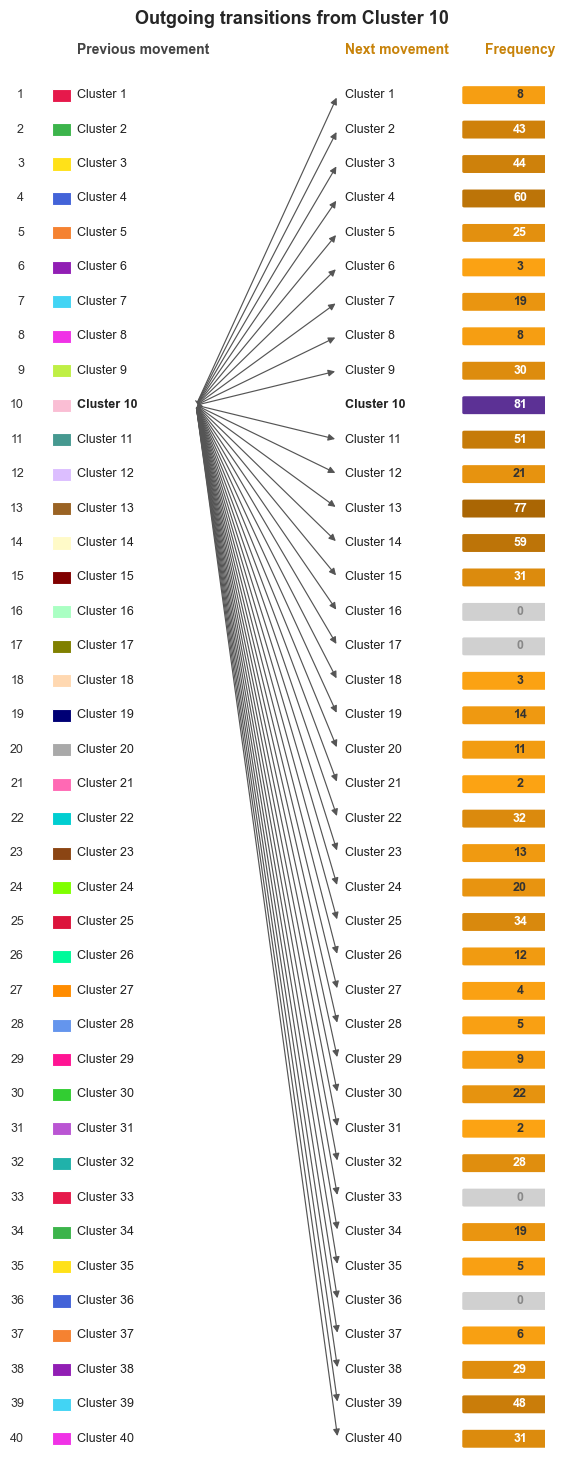

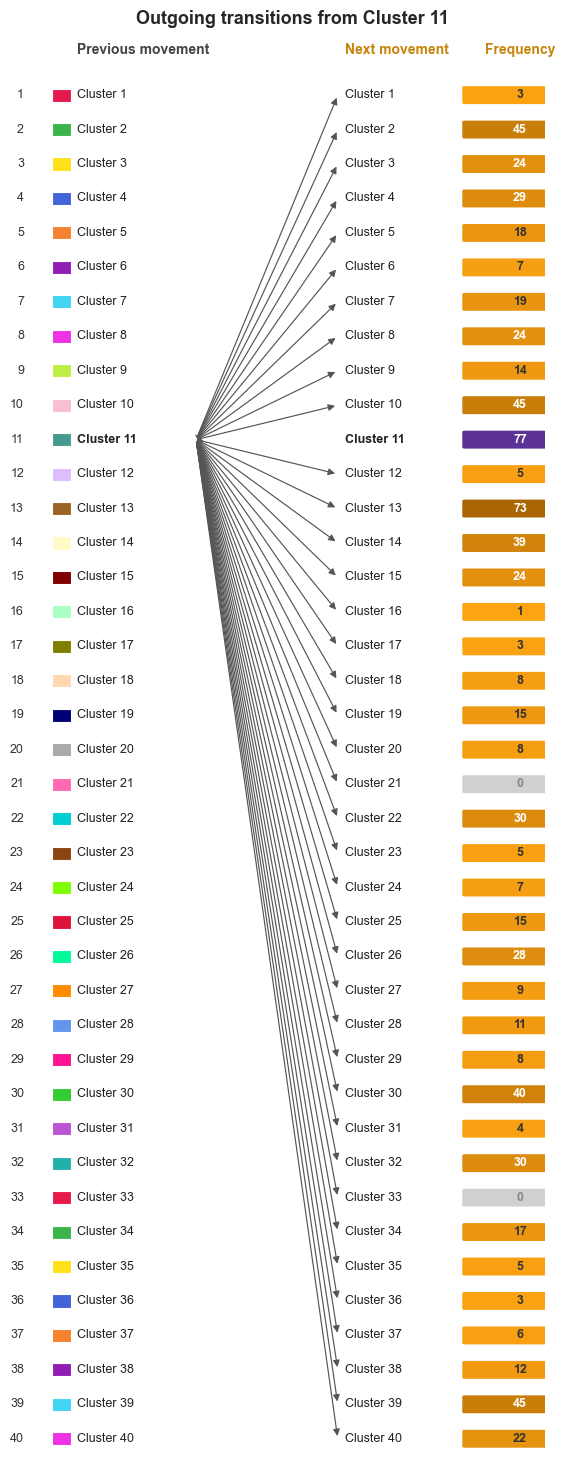

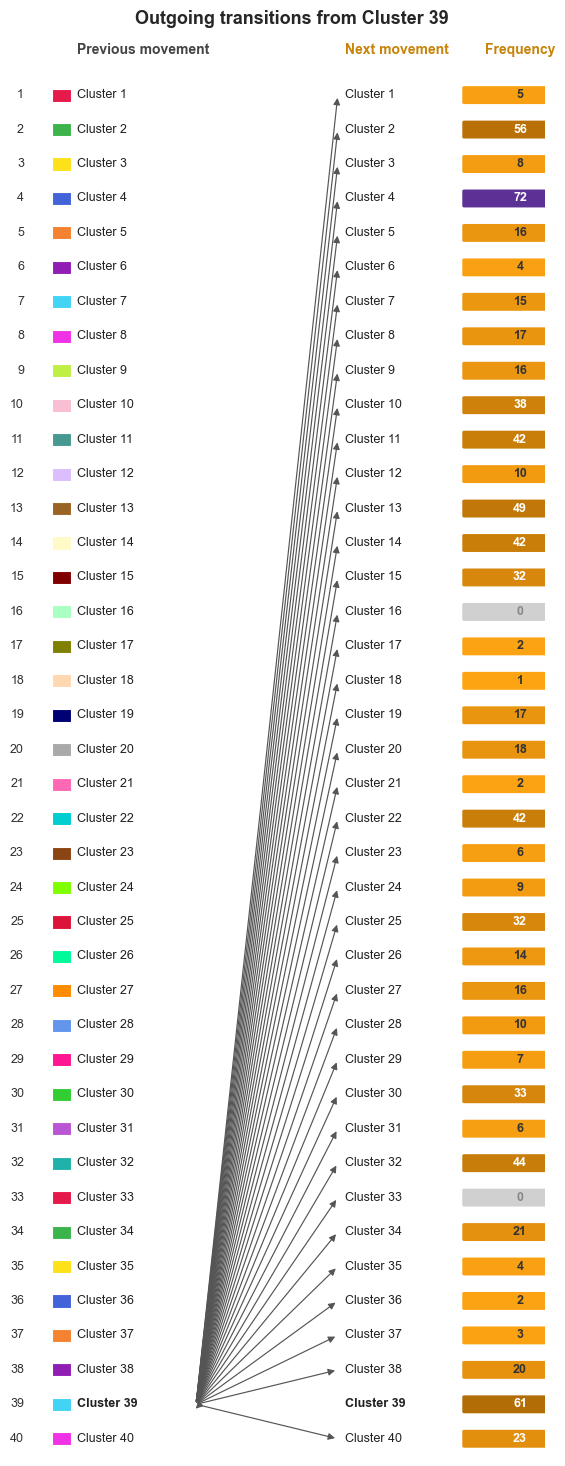

In [82]:
clusters = [10, 11, 39]
for mouse_name in df_all["Mouse"].unique():
    
    df_mouse = df_all[df_all["Mouse"] == mouse_name].copy()
    for c in clusters:
        fig = plot_cluster_transitions_table(df_mouse, c, figsize = (6, 15))
        fig.savefig(f"Cluster_Transition_Table_{c}.png", format="png")
        fig.show()

In [22]:
def plot_3d_vs_2d_top_transitions(df_mouse, mouse_name, top_n=10, reference="Baseline", save=False, path=None):
    """
    Gets top N transitions from the reference condition (Baseline or Inhibition),
    then finds those same transitions in the other condition.
    Plots a grouped bar chart side by side.

    Parameters
    ----------
    reference : str
        "Baseline" to rank by Baseline transitions, "Inhibition" to rank by Inhibition transitions.
    """

    if reference == "Baseline":
        ref_label  = "Baseline"
        comp_label = "Inhibition"
    elif reference == "Inhibition":
        ref_label  = "Inhibition"
        comp_label = "Baseline"
    else:
        raise ValueError(f"reference must be 'Baseline' or 'Inhibition', got '{reference}'")

    arena_groups = {
        "Baseline": ["Baseline"],
        "Inhibition": ["Inhibition"],
    }

    # --- pool transitions per group ---
    group_trans = {}
    for group_label, arenas in arena_groups.items():
        combined = Counter()
        for arena in arenas:
            df_arena = df_mouse[df_mouse["Arena"] == arena].copy()
            combined.update(pooled_transitions(df_arena, include_self_transitions=False))
        group_trans[group_label] = dict(combined)

    # --- normalize to probabilities ---
    def to_probs(trans):
        total = sum(trans.values())
        if total == 0:
            return {}
        return {k: v / total for k, v in trans.items()}

    probs_ref  = to_probs(group_trans[ref_label])
    probs_comp = to_probs(group_trans[comp_label])

    if len(probs_ref) == 0:
        print(f"No {ref_label} transitions for {mouse_name}")
        return

    # --- get top N transitions by reference probability ---
    top_transitions = sorted(probs_ref, key=probs_ref.get, reverse=True)[:top_n]

    labels    = [f"{c1} → {c2}" for (c1, c2) in top_transitions]
    vals_ref  = [probs_ref.get(t, 0)  for t in top_transitions]
    vals_comp = [probs_comp.get(t, 0) for t in top_transitions]

    # --- plot ---
    x = np.arange(len(labels))
    bar_width = 0.35

    ref_color  = "steelblue" if ref_label  == "Baseline" else "white"
    comp_color = "steelblue" if comp_label == "Baseline" else "white"

    fig, ax = plt.subplots(figsize=(14, 7))

    ax.bar(x - bar_width / 2, vals_ref,  width=bar_width, label=ref_label,  color=ref_color,  edgecolor="black", linewidth=0.8)
    ax.bar(x + bar_width / 2, vals_comp, width=bar_width, label=comp_label, color=comp_color, edgecolor="black", linewidth=0.8)

    # --- mark bars that are zero (transition absent in that condition) ---
    for i, v in enumerate(vals_comp):
        if v == 0:
            ax.text(
                x[i] + bar_width / 2,
                0.0005,
                "n/a",
                ha="center",
                va="bottom",
                fontsize=8,
                color="gray"
            )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_xlabel("Transition")
    ax.set_ylabel("Transition Probability")
    ax.set_title(f"{mouse_name} — Top {top_n} {ref_label} Transitions vs {comp_label}")
    ax.legend()
    sns.despine()
    plt.tight_layout()
    if save and path:
        plt.savefig(path, dpi=300)
    plt.show()

    # --- print table ---
    df_out = pd.DataFrame({
        "Transition":               labels,
        f"{ref_label} Probability":  vals_ref,
        f"{comp_label} Probability": vals_comp,
        f"In {comp_label}":         ["Yes" if v > 0 else "No" for v in vals_comp]
    })
    print(f"\n{mouse_name} — Top {top_n} {ref_label} Transitions vs {comp_label}")
    print(df_out.to_string(index=False))

    return df_out

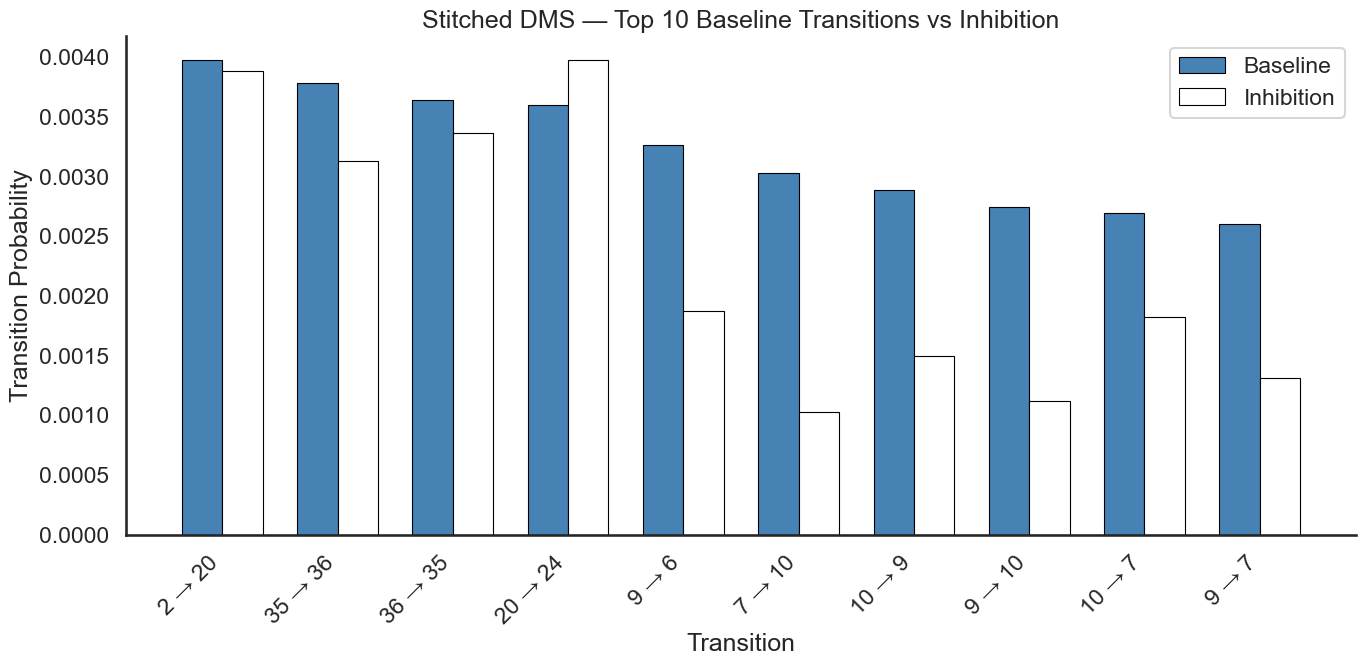


Stitched DMS — Top 10 Baseline Transitions vs Inhibition
Transition  Baseline Probability  Inhibition Probability In Inhibition
    2 → 20              0.003976                0.003882           Yes
   35 → 36              0.003787                0.003133           Yes
   36 → 35              0.003645                0.003367           Yes
   20 → 24              0.003597                0.003975           Yes
     9 → 6              0.003266                0.001871           Yes
    7 → 10              0.003029                0.001029           Yes
    10 → 9              0.002887                0.001497           Yes
    9 → 10              0.002745                0.001122           Yes
    10 → 7              0.002698                0.001824           Yes
     9 → 7              0.002603                0.001309           Yes


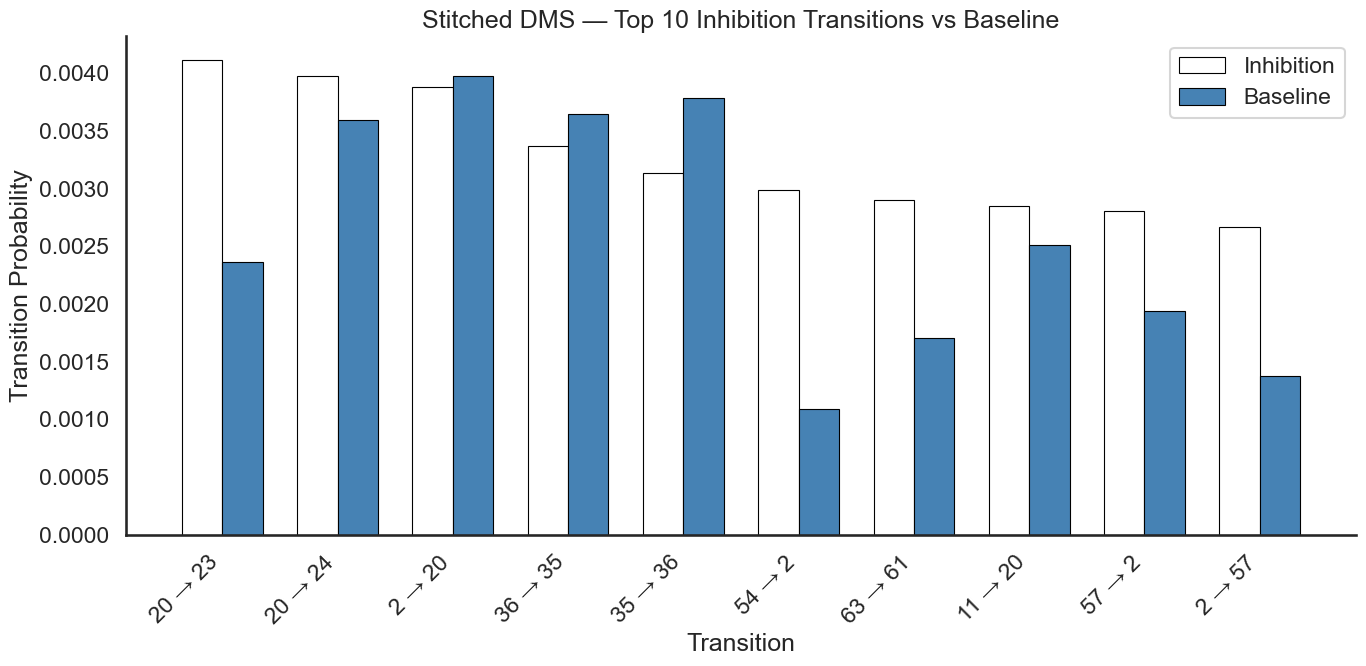


Stitched DMS — Top 10 Inhibition Transitions vs Baseline
Transition  Inhibition Probability  Baseline Probability In Baseline
   20 → 23                0.004115              0.002367         Yes
   20 → 24                0.003975              0.003597         Yes
    2 → 20                0.003882              0.003976         Yes
   36 → 35                0.003367              0.003645         Yes
   35 → 36                0.003133              0.003787         Yes
    54 → 2                0.002993              0.001089         Yes
   63 → 61                0.002899              0.001704         Yes
   11 → 20                0.002853              0.002509         Yes
    57 → 2                0.002806              0.001941         Yes
    2 → 57                0.002666              0.001373         Yes


In [23]:
for mouse_name in df_all["Mouse"].unique():
    df_mouse = df_all[df_all["Mouse"] == mouse_name].copy()
    plot_3d_vs_2d_top_transitions(df_mouse, mouse_name, top_n=10, reference="Baseline", save=True, path=f"{mouse_name}_Baseline_vs_Inhibition_top_transitions.png").to_csv(f"{mouse_name}_Baseline_vs_Inhibition_top_transitions.csv", index=False)
    plot_3d_vs_2d_top_transitions(df_mouse, mouse_name, top_n=10, reference="Inhibition", save=True, path=f"{mouse_name}_Inhibition_vs_Baseline_top_transitions.png").to_csv(f"{mouse_name}_Inhibition_vs_Baseline_top_transitions.csv", index=False)

In [25]:
def plot_cluster_counts(df_mouse, mouse_name, cluster_labels, save=False):
    """
    Plots two separate figures:
      - Figure 1: total cluster counts across all data
      - Figure 2: Baseline vs Inhibition side by side

    Parameters
    ----------
    df_mouse : pd.DataFrame
        DataFrame with columns: Timestamp, ClusterIdx, Arena.
    mouse_name : str
        Name of the mouse (used in title).
    cluster_labels : list of int
        List of cluster labels to include, e.g. [2, 4, 6, 8].
    """

    def summarize_cluster_counts(df):
        total_counts      = df.groupby("ClusterIdx").size().rename("Total Count")
        baseline_counts   = df[df["Arena"] == "Baseline"].groupby("ClusterIdx").size().rename("Baseline Count")
        inhibition_counts = df[df["Arena"] == "Inhibition"].groupby("ClusterIdx").size().rename("Inhibition Count")

        df_out = (
            pd.concat([total_counts, baseline_counts, inhibition_counts], axis=1)
            .fillna(0)
            .astype(int)
            .reset_index()
        )
        return df_out.sort_values("ClusterIdx").reset_index(drop=True)

    df_filtered = df_mouse[df_mouse["ClusterIdx"].isin(cluster_labels)]

    total_counts = (
        df_filtered["ClusterIdx"]
        .value_counts()
        .reindex(cluster_labels, fill_value=0)
    )

    baseline_counts = (
        df_filtered[df_filtered["Arena"] == "Baseline"]["ClusterIdx"]
        .value_counts()
        .reindex(cluster_labels, fill_value=0)
    )

    inhibition_counts = (
        df_filtered[df_filtered["Arena"] == "Inhibition"]["ClusterIdx"]
        .value_counts()
        .reindex(cluster_labels, fill_value=0)
    )

    x         = np.arange(len(cluster_labels))
    bar_width = 0.35
    xlabels   = [str(c) for c in cluster_labels]

    # --- plot 1: total counts ---
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x, total_counts.values, width=0.6, color="steelblue",
           edgecolor="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Count")
    ax.set_title(f"{mouse_name} — Cluster Counts (All Data)")
    sns.despine()
    plt.tight_layout()
    if save:
        plt.savefig(f"{mouse_name}_Cluster_Counts_All.png", dpi=300)
    plt.show()

    # --- plot 2: baseline vs inhibition ---
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - bar_width / 2, baseline_counts.values,   width=bar_width,
           label="Baseline",   color="steelblue", edgecolor="black", linewidth=0.8)
    ax.bar(x + bar_width / 2, inhibition_counts.values, width=bar_width,
           label="Inhibition", color="white",     edgecolor="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Count")
    ax.set_title(f"{mouse_name} — Cluster Counts (Baseline vs Inhibition)")
    ax.legend()
    sns.despine()
    plt.tight_layout()
    if save:
        plt.savefig(f"{mouse_name}_Cluster_Counts_Conditions.png", dpi=300)
    plt.show()

    summarize_cluster_counts(df_mouse).to_csv(f"{mouse_name}_Cluster_Counts.csv", index=False)

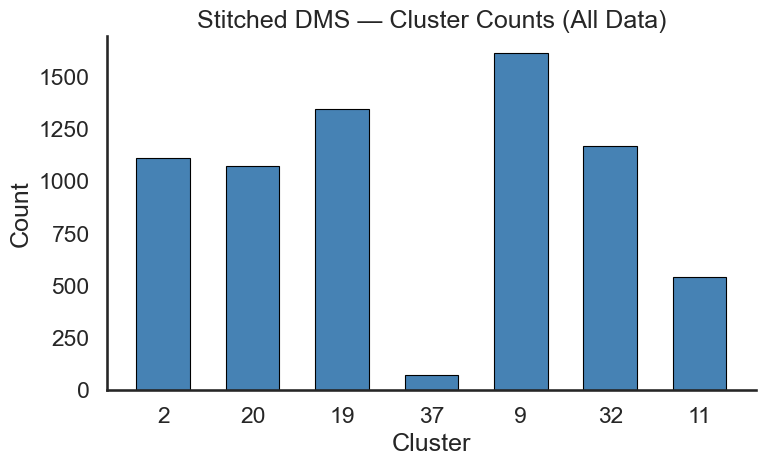

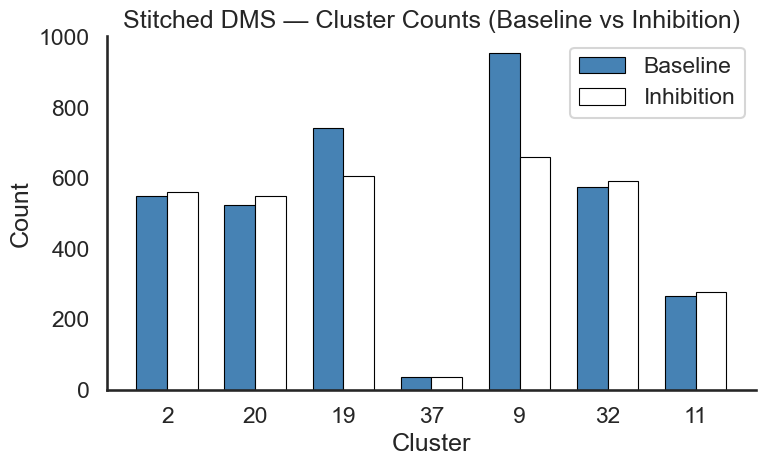

In [26]:
cluster_labels = [2, 20, 19, 37, 9, 32, 11]
for mouse_name in df_all["Mouse"].unique():
    df_mouse = df_all[df_all["Mouse"] == mouse_name].copy()
    plot_cluster_counts(df_mouse, mouse_name, cluster_labels, save=True)

In [20]:
def plot_transition_probability_change(df_mouse, mouse_name, top_n=10, reference="Baseline", save=False, path=None):
    """
    Gets top N transitions from the reference condition, then plots a single bar
    per transition showing the change in probability (Inhibition − Baseline).

    Bars above zero = transition becomes more likely under Inhibition.
    Bars below zero = transition becomes less likely under Inhibition.

    Parameters
    ----------
    reference : str
        "Baseline" to rank by Baseline transitions, "Inhibition" to rank by Inhibition transitions.
    """

    if reference == "Baseline":
        ref_label  = "Baseline"
        comp_label = "Inhibition"
    elif reference == "Inhibition":
        ref_label  = "Inhibition"
        comp_label = "Baseline"
    else:
        raise ValueError(f"reference must be 'Baseline' or 'Inhibition', got '{reference}'")

    arena_groups = {
        "Baseline":   ["Baseline"],
        "Inhibition": ["Inhibition"],
    }

    # --- pool transitions per group ---
    group_trans = {}
    for group_label, arenas in arena_groups.items():
        combined = Counter()
        for arena in arenas:
            df_arena = df_mouse[df_mouse["Arena"] == arena].copy()
            combined.update(pooled_transitions(df_arena, include_self_transitions=False))
        group_trans[group_label] = dict(combined)

    # --- normalize to probabilities ---
    def to_probs(trans):
        total = sum(trans.values())
        if total == 0:
            return {}
        return {k: v / total for k, v in trans.items()}

    probs_ref  = to_probs(group_trans[ref_label])
    probs_comp = to_probs(group_trans[comp_label])

    if len(probs_ref) == 0:
        print(f"No {ref_label} transitions for {mouse_name}")
        return

    # --- get top N transitions by reference probability ---
    top_transitions = sorted(probs_ref, key=probs_ref.get, reverse=True)[:top_n]

    labels    = [f"{c1} → {c2}" for (c1, c2) in top_transitions]
    vals_ref  = [probs_ref.get(t, 0)  for t in top_transitions]
    vals_comp = [probs_comp.get(t, 0) for t in top_transitions]

    # --- compute % change: (comp − ref) / ref × 100 ---
    pct_changes = [
        ((vc - vr) / vr * 100) if vr > 0 else float("nan")
        for vr, vc in zip(vals_ref, vals_comp)
    ]

    # --- color bars by direction (skip NaN) ---
    bar_colors = [
        "steelblue" if (not np.isnan(d) and d >= 0) else "tomato"
        for d in pct_changes
    ]

    # --- plot ---
    x = np.arange(len(labels))
    bar_width = 0.6

    fig, ax = plt.subplots(figsize=(14, 7))

    bars = ax.bar(x, pct_changes, width=bar_width, color=bar_colors, edgecolor="black", linewidth=0.8)

    # --- zero reference line ---
    ax.axhline(0, color="black", linewidth=0.9, linestyle="--")

    # --- annotate bars where ref probability was zero (undefined % change) ---
    for i, (d, vr) in enumerate(zip(pct_changes, vals_ref)):
        if np.isnan(d):
            ax.text(x[i], 0.05, "n/a\n(ref=0)", ha="center", va="bottom", fontsize=8, color="gray")

    # --- legend proxy patches ---
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="steelblue",    edgecolor="black", label=f"Increase under {comp_label}"),
        Patch(facecolor="tomato", edgecolor="black", label=f"Decrease under {comp_label}"),
    ]
    ax.legend(handles=legend_elements)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_xlabel("Transition")
    ax.set_ylabel(f"% Change  ({comp_label} vs {ref_label})")
    ax.set_title(f"{mouse_name} — % Change in Top {top_n} {ref_label} Transition Probabilities")

    sns.despine()
    plt.tight_layout()

    if save and path:
        plt.savefig(path, dpi=300)
    plt.show()

    # --- print table ---
    df_out = pd.DataFrame({
        "Transition":                labels,
        f"{ref_label} Probability":  vals_ref,
        f"{comp_label} Probability": vals_comp,
        "% Change":                  [f"{d:+.1f}%" if not np.isnan(d) else "n/a" for d in pct_changes],
        "Direction":                 [
            "↑" if (not np.isnan(d) and d > 0) else ("↓" if (not np.isnan(d) and d < 0) else "=")
            for d in pct_changes
        ],
    })
    print(f"\n{mouse_name} — ΔP for Top {top_n} {ref_label} Transitions")
    print(df_out.to_string(index=False))

    return df_out

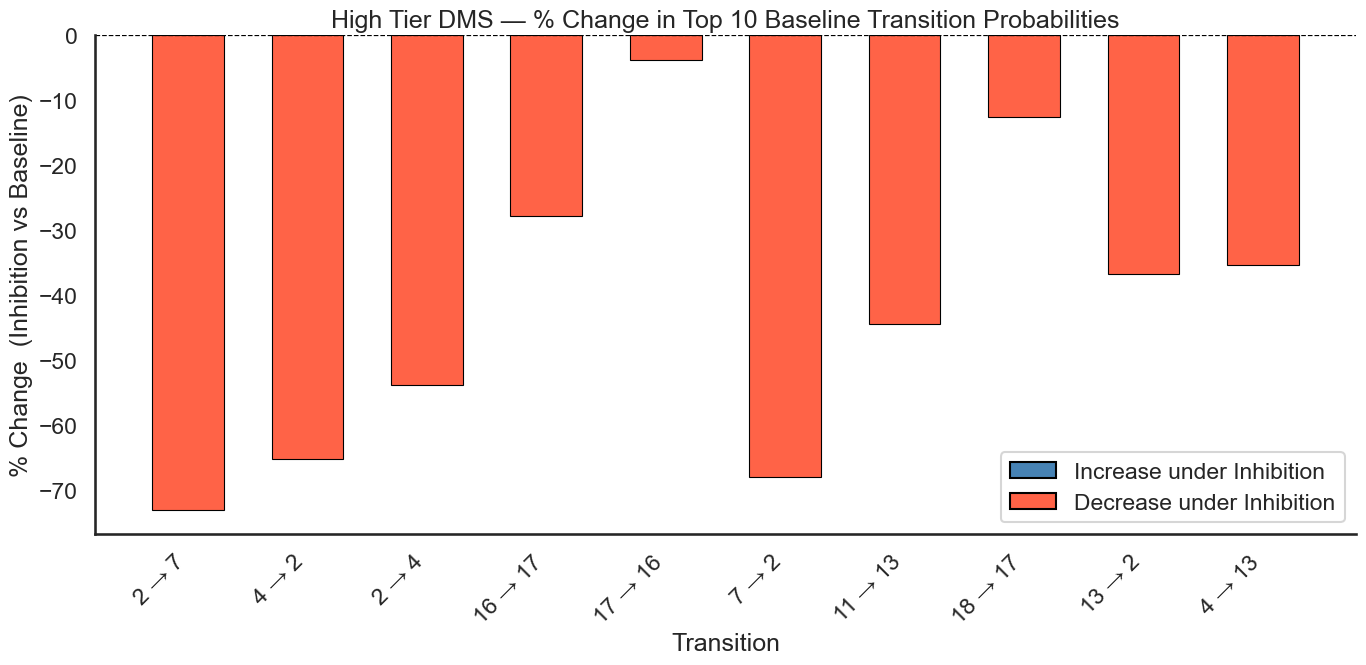


High Tier DMS — ΔP for Top 10 Baseline Transitions
Transition  Baseline Probability  Inhibition Probability % Change Direction
     2 → 7              0.005280                0.001418   -73.1%         ↓
     4 → 2              0.004903                0.001702   -65.3%         ↓
     2 → 4              0.004714                0.002175   -53.9%         ↓
   16 → 17              0.004714                0.003404   -27.8%         ↓
   17 → 16              0.004620                0.004444    -3.8%         ↓
     7 → 2              0.004431                0.001418   -68.0%         ↓
   11 → 13              0.004431                0.002458   -44.5%         ↓
   18 → 17              0.004431                0.003876   -12.5%         ↓
    13 → 2              0.004337                0.002742   -36.8%         ↓
    4 → 13              0.004243                0.002742   -35.4%         ↓


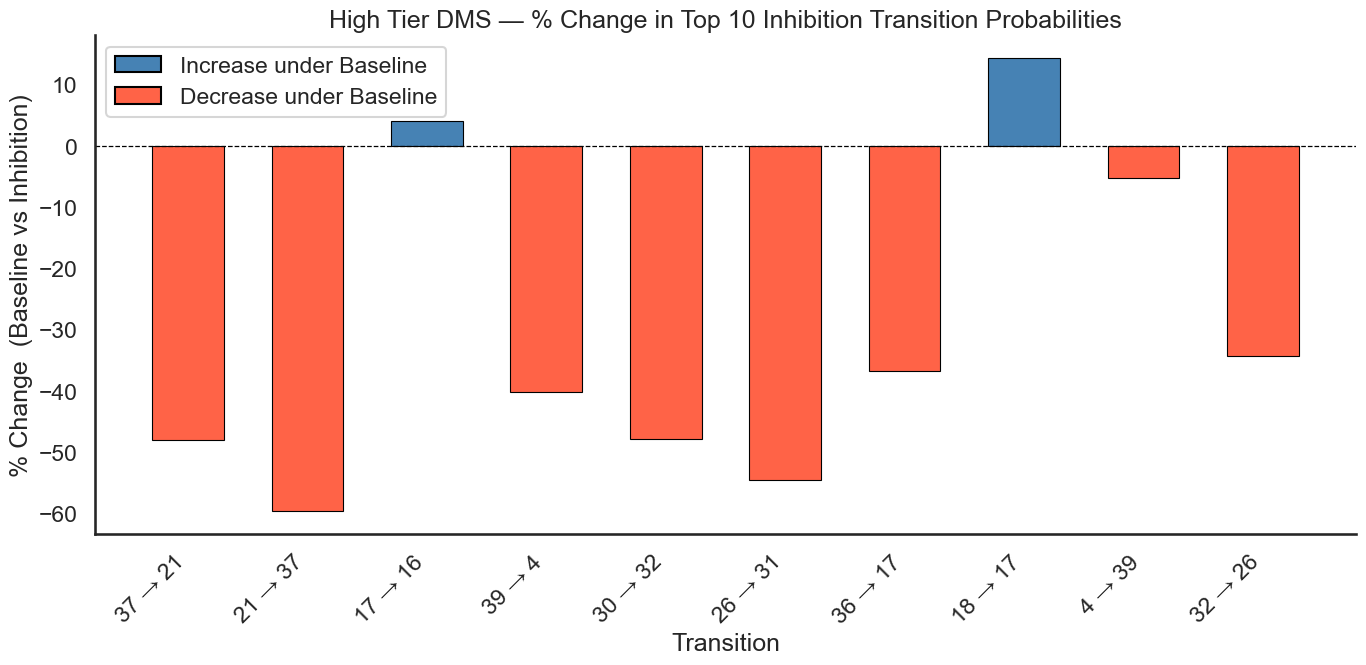


High Tier DMS — ΔP for Top 10 Inhibition Transitions
Transition  Inhibition Probability  Baseline Probability % Change Direction
   37 → 21                0.004538              0.002357   -48.1%         ↓
   21 → 37                0.004444              0.001791   -59.7%         ↓
   17 → 16                0.004444              0.004620    +4.0%         ↑
    39 → 4                0.004255              0.002546   -40.2%         ↓
   30 → 32                0.004160              0.002169   -47.9%         ↓
   26 → 31                0.004160              0.001886   -54.7%         ↓
   36 → 17                0.003876              0.002451   -36.8%         ↓
   18 → 17                0.003876              0.004431   +14.3%         ↑
    4 → 39                0.003782              0.003583    -5.3%         ↓
   32 → 26                0.003593              0.002357   -34.4%         ↓


In [21]:
for mouse_name in df_all["Mouse"].unique():
    df_mouse = df_all[df_all["Mouse"] == mouse_name].copy()
    plot_transition_probability_change(df_mouse, mouse_name, top_n=10, reference="Baseline", save=True, path=f"{mouse_name}_Baseline_vs_Inhibition_transition_change.png").to_csv(f"{mouse_name}_Baseline_vs_Inhibition_transition_change.csv", index=False)
    plot_transition_probability_change(df_mouse, mouse_name, top_n=10, reference="Inhibition", save=True, path=f"{mouse_name}_Inhibition_vs_Baseline_transition_change.png").to_csv(f"{mouse_name}_Inhibition_vs_Baseline_transition_change.csv", index=False)

In [19]:
def plot_cluster_change(df_mouse: pd.DataFrame, mouse_name: str, save: bool = False, path: str = None):

    grouped = df_mouse.groupby("ClusterIdx")["Arena"].value_counts()
    dict = { "ClusterIdx": [], "Baseline_norm": [], "Inhibition_norm": [] }
    for cluster_idx in df_mouse["ClusterIdx"].unique():
        counts = grouped[cluster_idx]
        baseline_count = counts.get("Baseline", 0)
        inhibition_count = counts.get("Inhibition", 0)
        total = baseline_count + inhibition_count

        if total > 0:
            baseline_norm = baseline_count / total
            inhibition_norm = inhibition_count / total
        else:
            baseline_norm = 0
            inhibition_norm = 0

        dict["ClusterIdx"].append(cluster_idx)
        dict["Baseline_norm"].append(baseline_norm)
        dict["Inhibition_norm"].append(inhibition_norm)
    df = pd.DataFrame(dict)

    # --- plot ---
    x = df_mouse["ClusterIdx"].unique()
    bar_width = 0.6

    fig, ax = plt.subplots(figsize=(14, 7))
    pct_changes =  df["Inhibition_norm"] - df["Baseline_norm"]
    df["Percentage_Change"] = pct_changes

    bar_colors = [
        "steelblue" if (not np.isnan(d) and d >= 0) else "tomato"
        for d in pct_changes
    ]

    bars = ax.bar(x, pct_changes, width=bar_width, color=bar_colors, edgecolor="black", linewidth=0.8)

    # --- zero reference line ---
    ax.axhline(0, color="black", linewidth=0.9, linestyle="--")

    # --- annotate bars where ref probability was zero (undefined % change) ---
    # for i, (d, vr) in enumerate(zip(pct_changes, vals_ref)):
    #     if np.isnan(d):
    #         ax.text(x[i], 0.05, "n/a\n(ref=0)", ha="center", va="bottom", fontsize=8, color="gray")

    # --- legend proxy patches ---
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="steelblue",    edgecolor="black", label=f"Increase from Baseline to Inhibition"),
        Patch(facecolor="tomato", edgecolor="black", label=f"Decrease from Baseline to Inhibition"),
    ]
    ax.legend(handles=legend_elements)

    ax.set_xticks(x)
    ax.set_xticklabels(x, rotation=45, ha="right")
    ax.set_xlabel("Transition")
    ax.set_ylabel(f"% Change Baseline → Inhibition")
    ax.set_title(f"{mouse_name} — % Change in Cluster Proportions from Baseline to Inhibition")

    sns.despine()
    plt.tight_layout()
    
    if save and path:
        plt.savefig(path, dpi=300)
        df.to_csv(f"{path}_data.csv", index=False)
    plt.show()

    return df

        

In [20]:
def plot_cluster_change_filtered(cluster_change_df: pd.DataFrame, 
                                 mouse_name: str, 
                                 thresholds: dict = {"increase": 0.4, "decrease": -0.4, "sustain": (-0.2, 0.2)},
                                 save: bool = False, 
                                 path: str = None):
    
    # Increase in cluster change plot
    increase_df = cluster_change_df[cluster_change_df["Percentage_Change"] >= thresholds["increase"]].copy()
    increase_plot_df = pd.DataFrame({"Arena": ["Baseline" for _ in range(len(increase_df))] + ["Inhibition" for _ in range(len(increase_df))],
                                        "Proportion": list(increase_df["Baseline_norm"]) + list(increase_df["Inhibition_norm"]),
                                        "ClusterIdx": list(increase_df["ClusterIdx"]) + list(increase_df["ClusterIdx"])})

    # Ensure ordering
    increase_plot_df["Arena"] = pd.Categorical(
        increase_plot_df["Arena"],
        categories=["Baseline", "Inhibition"],
        ordered=True
    )

    plt.figure(figsize=(8, 6))
    sns.lineplot(
        data=increase_plot_df,
        x="Arena",
        y="Proportion",
        hue="ClusterIdx",
        marker="o",
        legend="full",
        palette="Blues"
    )
    plt.ylabel("Proportion")
    plt.xlabel("Arena")
    plt.ylim(0, 1)
    plt.title("Proportion by Arena for Increasing Clusters")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    plt.tight_layout()
    plt.show()

    # Decrease in cluster change plot
    decrease_df = cluster_change_df[cluster_change_df["Percentage_Change"] <= thresholds["decrease"]].copy()
    decrease_plot_df = pd.DataFrame({"Arena": ["Baseline" for _ in range(len(decrease_df))] + ["Inhibition" for _ in range(len(decrease_df))],
                                        "Proportion": list(decrease_df["Baseline_norm"]) + list(decrease_df["Inhibition_norm"]),
                                        "ClusterIdx": list(decrease_df["ClusterIdx"]) + list(decrease_df["ClusterIdx"])})

    # Ensure ordering
    decrease_plot_df["Arena"] = pd.Categorical(
        decrease_plot_df["Arena"],
        categories=["Baseline", "Inhibition"],
        ordered=True
    )

    plt.figure(figsize=(8, 6))
    sns.lineplot(
        data=decrease_plot_df,
        x="Arena",
        y="Proportion",
        hue="ClusterIdx",
        marker="o",
        legend="full",
        palette="Reds"
    )
    plt.ylabel("Proportion")
    plt.xlabel("Arena")
    plt.ylim(0, 1)
    plt.title("Proportion by Arena for Decreasing Clusters")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    plt.tight_layout()
    plt.show()

    # Sustain in cluster change plot
    sustain_df = cluster_change_df[cluster_change_df["Percentage_Change"].between(thresholds["sustain"][0], thresholds["sustain"][1])].copy()
    sustain_plot_df = pd.DataFrame({"Arena": ["Baseline" for _ in range(len(sustain_df))] + ["Inhibition" for _ in range(len(sustain_df))],
                                        "Proportion": list(sustain_df["Baseline_norm"]) + list(sustain_df["Inhibition_norm"]),
                                        "ClusterIdx": list(sustain_df["ClusterIdx"]) + list(sustain_df["ClusterIdx"])})

    # Ensure ordering
    sustain_plot_df["Arena"] = pd.Categorical(
        sustain_plot_df["Arena"],
        categories=["Baseline", "Inhibition"],
        ordered=True
    )

    plt.figure(figsize=(8, 6))
    sns.lineplot(
        data=sustain_plot_df,
        x="Arena",
        y="Proportion",
        hue="ClusterIdx",
        marker="o",
        legend="full",
        palette="Greens"
    )
    plt.ylabel("Proportion")
    plt.xlabel("Arena")
    plt.ylim(0, 1)
    plt.title("Proportion by Arena for Sustained Clusters")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    plt.tight_layout()
    plt.show()

    

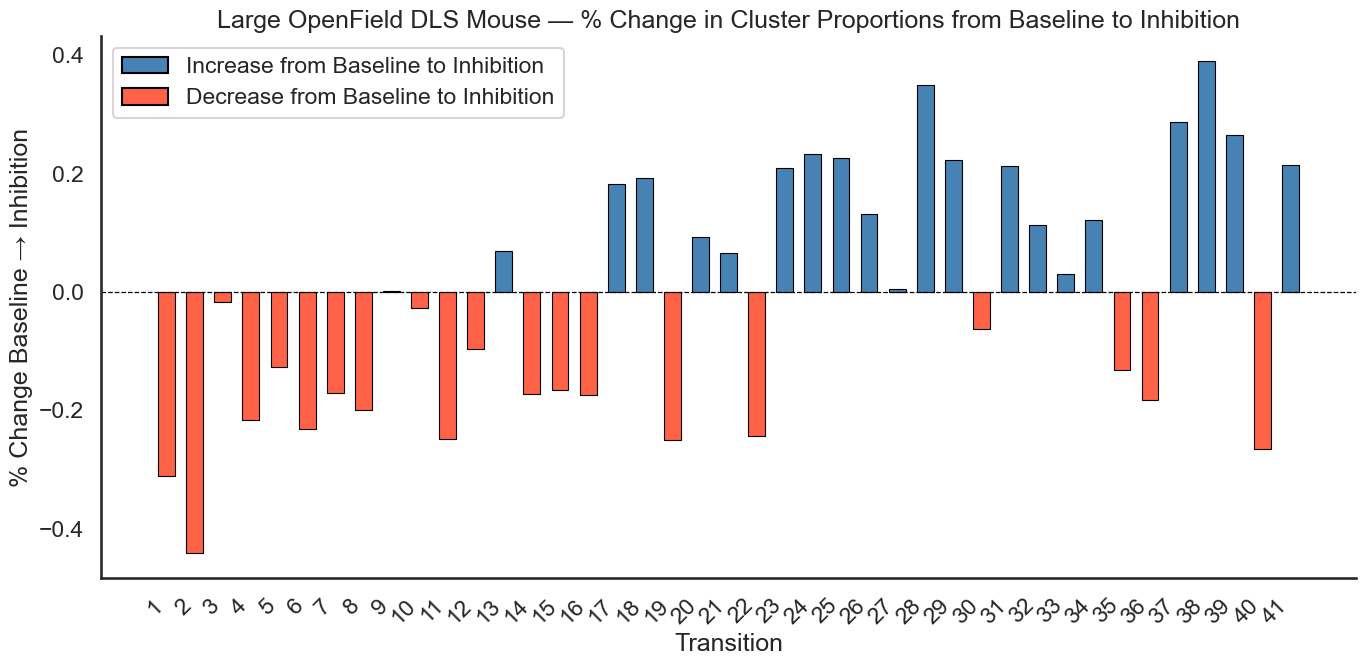

C:\Users\gangliagurdian\AppData\Local\Temp\ipykernel_41716\271067531.py:21: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(
C:\Users\gangliagurdian\AppData\Local\Temp\ipykernel_41716\271067531.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)


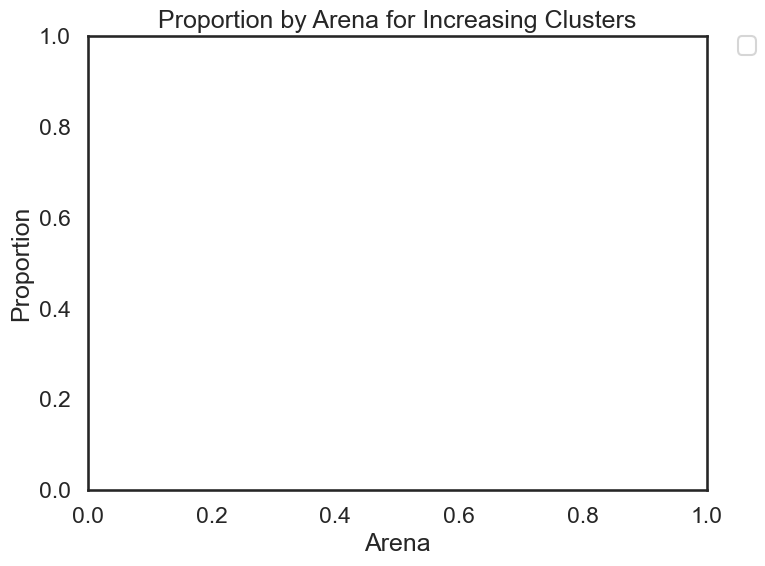

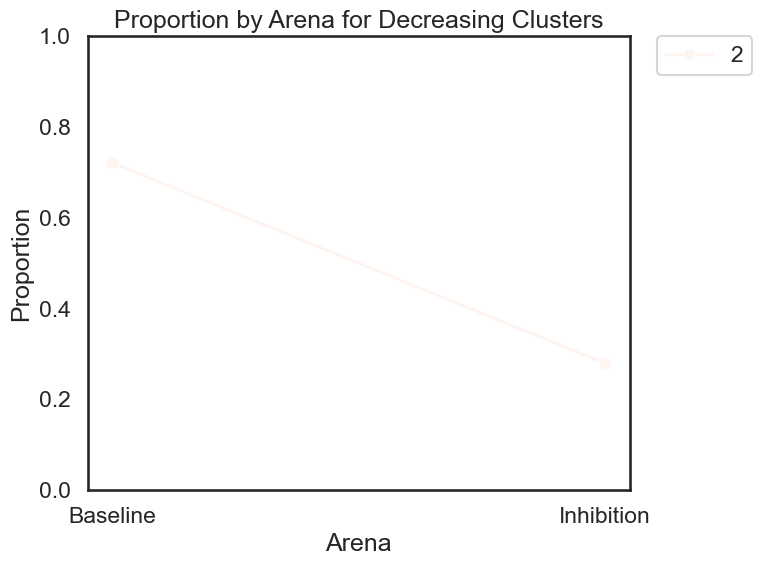

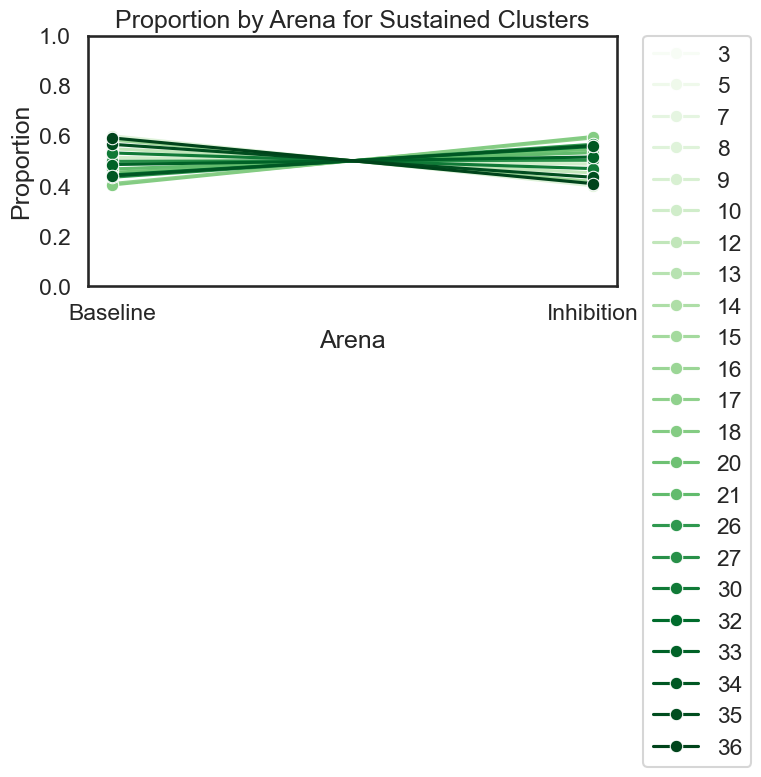

In [21]:
for mouse_name in df_all["Mouse"].unique():
    df_mouse = df_all[df_all["Mouse"] == mouse_name].copy()
    cluster_change_df = plot_cluster_change(df_mouse, mouse_name, save=False, path=f"{mouse_name}_Cluster_Change_Baseline_to_Inhibition.png")
    plot_cluster_change_filtered(cluster_change_df, mouse_name, save=False, path=f"{mouse_name}_Cluster_Change_Filtered.png")

In [27]:


df = pd.read_csv(r"X:\3darena_chemogenetic\c1_041626\042126_m2_dls\cluster_output_042126_m2_dls_large_open_field+bl+i\Combined_Results\Results\test1\combined_results_dls_largeof_with_features.csv")
df["Condition"] = df["Folder_Name"].map({1.0: "Baseline", 2.0: "Inhibition"})

In [31]:
df["Cluster"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41])

In [34]:
df

,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,Feature8,Feature9,Feature10,...,Timestamp,Cluster,Folder_Name,Week_Number,Group,anterior_posterior_x_accel,dorsal_ventral_y_accel,y_gyro,TotAccelBA,Condition
0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.116667,0.516667,...,4965.2413,1,1_baseline,1,13,0.958563,-0.124952,-8.220164,0.237199,NaN
1,0.0,0.0,0.0,0.0,0.0,0.0,0.050000,0.000000,0.133333,0.266667,...,4965.5412,1,1_baseline,1,13,0.983117,-0.031612,11.561076,0.348631,NaN
2,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.033333,0.350000,0.233333,...,4965.8410,1,1_baseline,1,13,0.958433,-0.134910,0.561015,0.583516,NaN
3,0.0,0.0,0.0,0.0,0.0,0.0,0.033333,0.116667,0.083333,0.233333,...,4966.1409,1,1_baseline,1,13,0.979081,-0.082640,-4.840088,0.577515,NaN
4,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.183333,0.150000,0.233333,...,4966.4407,1,1_baseline,1,13,0.943083,-0.091195,8.601888,0.298987,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23765,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.066667,0.250000,0.683333,...,12761.7708,27,2_inhibition,2,11,0.791194,0.548541,-8.258057,0.127892,NaN
23766,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.216667,0.783333,...,12762.1358,18,2_inhibition,2,13,0.802006,0.499007,16.582743,0.143662,NaN
23767,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.016667,0.533333,...,12762.4808,4,2_inhibition,2,13,0.998836,-0.018929,48.453267,0.261479,NaN
23768,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.033333,0.300000,0.450000,...,12762.8258,31,2_inhibition,2,3,0.874425,0.273706,34.188334,0.283221,NaN


In [36]:
len(df[df["Week_Number"] == 1]["Cluster"].unique())

41

In [39]:
df[df["Week_Number"] == 2]

,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,Feature8,Feature9,Feature10,...,Timestamp,Cluster,Folder_Name,Week_Number,Group,anterior_posterior_x_accel,dorsal_ventral_y_accel,y_gyro,TotAccelBA,Condition
11907,0.0,0.0,0.05,0.250000,0.133333,0.250000,0.200000,0.116667,0.000000,0.000000,...,8565.350800,33,2_inhibition,2,4,-0.071631,0.845469,56.197611,0.488892,NaN
11908,0.0,0.0,0.00,0.000000,0.333333,0.233333,0.233333,0.200000,0.000000,0.000000,...,8565.745800,33,2_inhibition,2,4,0.070475,0.918536,-54.257711,0.211306,NaN
11909,0.0,0.0,0.00,0.000000,0.283333,0.500000,0.166667,0.050000,0.000000,0.000000,...,8566.087467,33,2_inhibition,2,4,0.019444,0.947290,56.818644,0.124056,NaN
11910,0.0,0.0,0.00,0.283333,0.366667,0.116667,0.233333,0.000000,0.000000,0.000000,...,8566.415800,22,2_inhibition,2,4,-0.161656,0.936509,6.715393,0.234860,NaN
11911,0.0,0.0,0.00,0.066667,0.400000,0.533333,0.000000,0.000000,0.000000,0.000000,...,8566.760800,3,2_inhibition,2,12,-0.130535,0.928129,-103.583272,0.126242,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23765,0.0,0.0,0.00,0.000000,0.000000,0.000000,0.000000,0.066667,0.250000,0.683333,...,12761.770800,27,2_inhibition,2,11,0.791194,0.548541,-8.258057,0.127892,NaN
23766,0.0,0.0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.216667,0.783333,...,12762.135800,18,2_inhibition,2,13,0.802006,0.499007,16.582743,0.143662,NaN
23767,0.0,0.0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.016667,0.533333,...,12762.480800,4,2_inhibition,2,13,0.998836,-0.018929,48.453267,0.261479,NaN
23768,0.0,0.0,0.00,0.000000,0.000000,0.000000,0.000000,0.033333,0.300000,0.450000,...,12762.825800,31,2_inhibition,2,3,0.874425,0.273706,34.188334,0.283221,NaN


In [28]:
def plot_cluster_accel(df, mouse_name, cluster_labels, save=False, path=None):

    df_filtered = df[df["Cluster"].isin(cluster_labels)].copy()

    means = (
        df_filtered
        .groupby(["Cluster", "Condition"])["TotAccelBA"]
        .mean()
        .reset_index()
    )

    x = np.arange(len(cluster_labels))
    bar_width = 0.45

    def safe_mean_accel(c, cond):
        row = means.query("Cluster == @c and Condition == @cond")["TotAccelBA"]
        return row.values[0] if len(row) > 0 else 0

    baseline_means   = [safe_mean_accel(c, "Baseline")   for c in cluster_labels]
    inhibition_means = [safe_mean_accel(c, "Inhibition") for c in cluster_labels]

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.bar(x - bar_width / 2, baseline_means,   width=bar_width, label="Baseline",
           color="steelblue", edgecolor="black", linewidth=0.8)
    ax.bar(x + bar_width / 2, inhibition_means, width=bar_width, label="Inhibition",
           color="white",     edgecolor="black", linewidth=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels([str(c) for c in cluster_labels])
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Mean TotAccelBA")
    ax.set_title(f"{mouse_name} — Mean TotAccelBA by Cluster")
    ax.legend()

    sns.despine()
    plt.tight_layout()

    if save and path:
        plt.savefig(path, dpi=300)
    plt.show()

    # --- save CSV ---
    df_out = pd.DataFrame({
        "Cluster":                  [str(c) for c in cluster_labels],
        "Baseline Mean TotAccelBA":   baseline_means,
        "Inhibition Mean TotAccelBA": inhibition_means,
    })
    csv_path = path.replace(".png", "_accel.csv") if path else f"{mouse_name}_cluster_accel.csv"
    df_out.to_csv(csv_path, index=False)
    print(f"Saved accel CSV to {csv_path}")

    return df_out


def plot_cluster_dwell_time(df, mouse_name, cluster_labels, save=False, path=None):

    def compute_dwell(df_cond):
        df_cond = df_cond.sort_values("Timestamp").reset_index(drop=True)

        dwells = []
        i = 0
        while i < len(df_cond):
            current_cluster = df_cond.loc[i, "Cluster"]
            start_time      = df_cond.loc[i, "Timestamp"]

            j = i + 1
            while j < len(df_cond) and df_cond.loc[j, "Cluster"] == current_cluster:
                j += 1

            end_time     = df_cond.loc[j - 1, "Timestamp"]
            duration_sec = end_time - start_time

            dwells.append({"Cluster": current_cluster, "Dwell_s": duration_sec})
            i = j

        return pd.DataFrame(dwells)

    records = []
    for condition in ["Baseline", "Inhibition"]:
        df_cond = df[df["Condition"] == condition].copy()
        if df_cond.empty:
            continue
        dwell_df = compute_dwell(df_cond)
        dwell_df["Condition"] = condition
        records.append(dwell_df)

    if not records:
        print(f"No dwell data found for {mouse_name}")
        return

    all_dwells = pd.concat(records, ignore_index=True)
    all_dwells = all_dwells[all_dwells["Cluster"].isin(cluster_labels)]

    means = (
        all_dwells
        .groupby(["Cluster", "Condition"])["Dwell_s"]
        .mean()
        .reset_index()
    )

    x = np.arange(len(cluster_labels))
    bar_width = 0.35

    def safe_mean(c, cond):
        row = means.query("Cluster == @c and Condition == @cond")["Dwell_s"]
        return row.values[0] if len(row) > 0 else 0

    baseline_dwells   = [safe_mean(c, "Baseline")   for c in cluster_labels]
    inhibition_dwells = [safe_mean(c, "Inhibition") for c in cluster_labels]

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.bar(x - bar_width / 2, baseline_dwells,   width=bar_width, label="Baseline",
           color="steelblue", edgecolor="black", linewidth=0.8)
    ax.bar(x + bar_width / 2, inhibition_dwells, width=bar_width, label="Inhibition",
           color="white",     edgecolor="black", linewidth=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels([str(c) for c in cluster_labels])
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Mean Dwell Time (s)")
    ax.set_title(f"{mouse_name} — Mean Dwell Time by Cluster")
    ax.legend()

    sns.despine()
    plt.tight_layout()

    if save and path:
        plt.savefig(path, dpi=300)
    plt.show()

    # --- save CSV ---
    df_out = pd.DataFrame({
        "Cluster":                    [str(c) for c in cluster_labels],
        "Baseline Mean Dwell (s)":    baseline_dwells,
        "Inhibition Mean Dwell (s)":  inhibition_dwells,
    })
    csv_path = path.replace(".png", "_dwell.csv") if path else f"{mouse_name}_cluster_dwell.csv"
    df_out.to_csv(csv_path, index=False)
    print(f"Saved dwell CSV to {csv_path}")

    return df_out

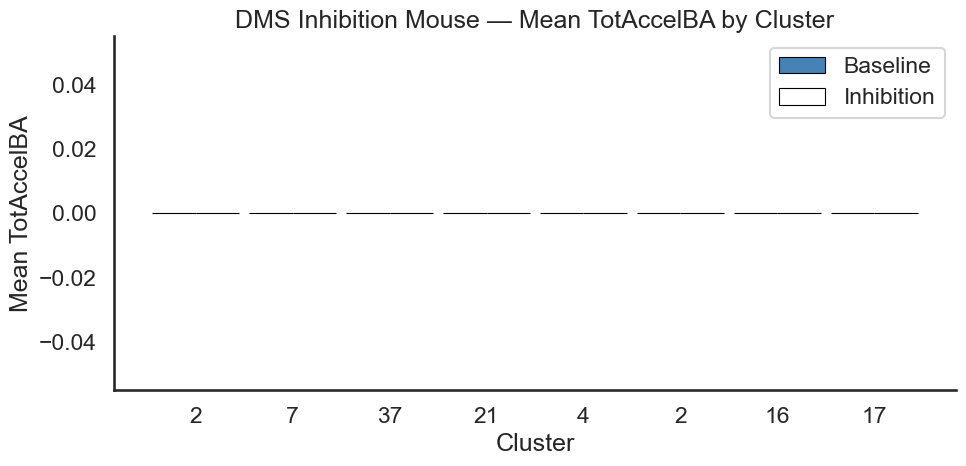

Saved accel CSV to DMS Inhibition Mouse_TotAccelBA_accel.csv
No dwell data found for DMS Inhibition Mouse


In [29]:
cluster_labels = [2, 7, 37, 21, 4, 2, 16, 17]
mouse_name = "DMS Inhibition Mouse"
plot_cluster_accel(df, mouse_name, cluster_labels, save=True, path=f"{mouse_name}_TotAccelBA.png")
plot_cluster_dwell_time(df, mouse_name, cluster_labels, save=True, path=f"{mouse_name}_Dwell_Time.png")